# LinkedIn Job Postings – Data Mining Notebook

Notebook tổng hợp cho đồ án *Khai phá dữ liệu* với 3 câu hỏi nghiên cứu:

- **RQ1:** Các mô tả công việc trên LinkedIn có tự nhiên hình thành những nhóm nội dung (job description themes) khác nhau hay không, khi không sử dụng bất kỳ nhãn nghề nghiệp hoặc kỹ năng có sẵn nào?
- **RQ2:** Các kỹ năng trong mô tả công việc có xu hướng đồng xuất hiện theo những mẫu nào, và những mẫu này phản ánh cấu trúc kỹ năng của thị trường lao động ra sao?
- **RQ3:** Những yếu tố nào trong thông tin tuyển dụng có ảnh hưởng đáng kể đến mức lương được công bố, và mức độ dự đoán lương từ các yếu tố này đến đâu?


# import libraries

In [1]:
import re

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
from mlxtend.preprocessing import TransactionEncoder
from networkx.algorithms.community import greedy_modularity_communities
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    RandomForestRegressor,
)
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.manifold import TSNE
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    silhouette_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.inspection import permutation_importance



plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
sns.set(style="whitegrid", font_scale=1.1)


In [2]:
def normalize_text(s: str) -> str:
    s = str(s).lower()
    s = re.sub(r"[^a-z0-9+# ]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

# 1. Load & Tổng quan dữ liệu

## 1.1 Load data

In [3]:
# Đặt đúng đường dẫn file trước khi chạy
JOB_POSTINGS_PATH = "../data/postings.csv"
COMPANIES_PATH = "../data/companies.csv"
EMP_COUNTS_PATH = "../data/employee_counts.csv"
JOB_SKILLS_PATH = "../data/job_skills.csv"
SKILL_MAP_PATH = "../data/skill_mapping.csv"

job_df = pd.read_csv(JOB_POSTINGS_PATH)
companies_df = pd.read_csv(COMPANIES_PATH)
emp_counts_df = pd.read_csv(EMP_COUNTS_PATH)
job_skills_df = pd.read_csv(JOB_SKILLS_PATH)
skill_map_df = pd.read_csv(SKILL_MAP_PATH)


In [4]:
# Gộp để lấy tên kỹ năng đầy đủ
job_skills_full = job_skills_df.merge(skill_map_df, on="skill_abr", how="left")

# Gom danh sách kỹ năng theo từng job_id
skills_per_job = (
    job_skills_full.dropna(subset=["skill_name"])
    .groupby("job_id")["skill_name"]
    .apply(list)
    .reset_index()
    .rename(columns={"skill_name": "linkedin_skills"})
)

In [5]:
job_df.head()

,job_id,company_name,title,description,max_salary,pay_period,location,company_id,views,med_salary,...,skills_desc,listed_time,posting_domain,sponsored,work_type,currency,compensation_type,normalized_salary,zip_code,fips
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,Job descriptionA leading real estate firm in N...,20.0,HOURLY,"Princeton, NJ",2774458.0,20.0,NaN,...,Requirements: \n\nWe are seeking a College or ...,1.713398e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,38480.0,8540.0,34021.0
1,1829192,NaN,Mental Health Therapist/Counselor,"At Aspen Therapy and Wellness , we are committ...",50.0,HOURLY,"Fort Collins, CO",NaN,1.0,NaN,...,NaN,1.712858e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,83200.0,80521.0,8069.0
2,10998357,The National Exemplar,Assitant Restaurant Manager,The National Exemplar is accepting application...,65000.0,YEARLY,"Cincinnati, OH",64896719.0,8.0,NaN,...,We are currently accepting resumes for FOH - A...,1.713278e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,55000.0,45202.0,39061.0
3,23221523,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,Senior Associate Attorney - Elder Law / Trusts...,175000.0,YEARLY,"New Hyde Park, NY",766262.0,16.0,NaN,...,This position requires a baseline understandin...,1.712896e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,157500.0,11040.0,36059.0
4,35982263,NaN,Service Technician,Looking for HVAC service tech with experience ...,80000.0,YEARLY,"Burlington, IA",NaN,3.0,NaN,...,NaN,1.713452e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,70000.0,52601.0,19057.0


In [6]:
companies_df.head()

,company_id,name,description,company_size,state,country,city,zip_code,address,url
0,1009,IBM,"At IBM, we do more than work. We create. We cr...",7.0,NY,US,"Armonk, New York",10504,International Business Machines Corp.,https://www.linkedin.com/company/ibm
1,1016,GE HealthCare,Every day millions of people feel the impact o...,7.0,0,US,Chicago,0,-,https://www.linkedin.com/company/gehealthcare
2,1025,Hewlett Packard Enterprise,Official LinkedIn of Hewlett Packard Enterpris...,7.0,Texas,US,Houston,77389,1701 E Mossy Oaks Rd Spring,https://www.linkedin.com/company/hewlett-packa...
3,1028,Oracle,We’re a cloud technology company that provides...,7.0,Texas,US,Austin,78741,2300 Oracle Way,https://www.linkedin.com/company/oracle
4,1033,Accenture,Accenture is a leading global professional ser...,7.0,0,IE,Dublin 2,0,Grand Canal Harbour,https://www.linkedin.com/company/accenture


In [7]:
emp_counts_df.head()

,company_id,employee_count,follower_count,time_recorded
0,391906,186,32508,1712346173
1,22292832,311,4471,1712346173
2,20300,1053,6554,1712346173
3,3570660,383,35241,1712346173
4,878353,52,26397,1712346173


In [8]:
skills_per_job.head()

,job_id,linkedin_skills
0,921716,"[Marketing, Sales]"
1,1218575,[Health Care Provider]
2,1829192,[Health Care Provider]
3,2264355,"[Design, Art/Creative, Information Technology]"
4,10998357,"[Management, Manufacturing]"


## 1.2 Thống kê mô tả

### 1.2.1 Độ lớn dữ liệu

In [9]:
print(f"job_df: {job_df.shape}")
print(f"companies_df: {companies_df.shape}")
print(f"emp_counts_df: {emp_counts_df.shape}")
print(f"skills_per_job_df: {skills_per_job.shape}")

job_df: (123849, 31)
companies_df: (24473, 10)
emp_counts_df: (35787, 4)
skills_per_job_df: (126807, 2)


### 1.2.2 Thông tin kiểu dữ liệu của data

In [10]:
job_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123849 entries, 0 to 123848
Data columns (total 31 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   job_id                      123849 non-null  int64  
 1   company_name                122130 non-null  object 
 2   title                       123849 non-null  object 
 3   description                 123842 non-null  object 
 4   max_salary                  29793 non-null   float64
 5   pay_period                  36073 non-null   object 
 6   location                    123849 non-null  object 
 7   company_id                  122132 non-null  float64
 8   views                       122160 non-null  float64
 9   med_salary                  6280 non-null    float64
 10  min_salary                  29793 non-null   float64
 11  formatted_work_type         123849 non-null  object 
 12  applies                     23320 non-null   float64
 13  original_liste

In [11]:
companies_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24473 entries, 0 to 24472
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   company_id    24473 non-null  int64  
 1   name          24472 non-null  object 
 2   description   24176 non-null  object 
 3   company_size  21699 non-null  float64
 4   state         24451 non-null  object 
 5   country       24473 non-null  object 
 6   city          24472 non-null  object 
 7   zip_code      24445 non-null  object 
 8   address       24451 non-null  object 
 9   url           24473 non-null  object 
dtypes: float64(1), int64(1), object(8)
memory usage: 1.9+ MB


In [12]:
emp_counts_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35787 entries, 0 to 35786
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   company_id      35787 non-null  int64
 1   employee_count  35787 non-null  int64
 2   follower_count  35787 non-null  int64
 3   time_recorded   35787 non-null  int64
dtypes: int64(4)
memory usage: 1.1 MB


In [13]:
skills_per_job.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126807 entries, 0 to 126806
Data columns (total 2 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   job_id           126807 non-null  int64 
 1   linkedin_skills  126807 non-null  object
dtypes: int64(1), object(1)
memory usage: 1.9+ MB


### 1.2.3 Thống kê mô tả

In [14]:
job_df.drop(columns="job_id").describe()

,max_salary,company_id,views,med_salary,min_salary,applies,original_listed_time,remote_allowed,expiry,closed_time,listed_time,sponsored,normalized_salary,zip_code,fips
count,2.979300e+04,1.221320e+05,122160.000000,6280.000000,2.979300e+04,23320.000000,1.238490e+05,15246.0,1.238490e+05,1.073000e+03,1.238490e+05,123849.0,3.607300e+04,102977.000000,96434.000000
mean,9.193942e+04,1.220401e+07,14.618247,22015.619876,6.491085e+04,10.591981,1.713152e+12,1.0,1.716213e+12,1.712928e+12,1.713204e+12,0.0,2.053270e+05,50400.491887,28713.879887
std,7.011101e+05,2.554143e+07,85.903598,52255.873846,4.959738e+05,29.047395,4.848209e+08,0.0,2.321394e+09,3.622893e+08,3.989122e+08,0.0,5.097627e+06,30252.232515,16015.929825
min,1.000000e+00,1.009000e+03,1.000000,0.000000,1.000000e+00,1.000000,1.701811e+12,1.0,1.712903e+12,1.712346e+12,1.711317e+12,0.0,0.000000e+00,1001.000000,1003.000000
25%,4.828000e+01,1.435200e+04,3.000000,18.940000,3.700000e+01,1.000000,1.712863e+12,1.0,1.715481e+12,1.712670e+12,1.712886e+12,0.0,5.200000e+04,24112.000000,13121.000000
50%,8.000000e+04,2.269650e+05,4.000000,25.500000,6.000000e+04,3.000000,1.713395e+12,1.0,1.716042e+12,1.712670e+12,1.713408e+12,0.0,8.150000e+04,48059.000000,29183.000000
75%,1.400000e+05,8.047188e+06,8.000000,2510.500000,1.000000e+05,8.000000,1.713478e+12,1.0,1.716088e+12,1.713283e+12,1.713484e+12,0.0,1.250000e+05,78201.000000,42077.000000
max,1.200000e+08,1.034730e+08,9975.000000,750000.000000,8.500000e+07,967.000000,1.713573e+12,1.0,1.729125e+12,1.713562e+12,1.713573e+12,0.0,5.356000e+08,99901.000000,56045.000000


In [15]:
companies_df.describe()

,company_id,company_size
count,2.447300e+04,21699.000000
mean,2.052239e+07,3.349233
std,3.165929e+07,1.904503
min,1.009000e+03,1.000000
25%,1.654040e+05,2.000000
50%,2.738154e+06,3.000000
75%,2.624142e+07,5.000000
max,1.034730e+08,7.000000


In [16]:
emp_counts_df.describe()

,company_id,employee_count,follower_count,time_recorded
count,3.578700e+04,35787.000000,3.578700e+04,3.578700e+04
mean,1.668254e+07,6715.874256,2.012616e+05,1.713163e+09
std,2.924722e+07,29400.984643,1.114733e+06,3.990869e+05
min,1.009000e+03,0.000000,0.000000e+00,1.712346e+09
25%,6.059650e+04,56.000000,2.738000e+03,1.712861e+09
50%,1.339209e+06,418.000000,1.617800e+04,1.713393e+09
75%,1.544092e+07,2945.000000,7.412950e+04,1.713472e+09
max,1.034730e+08,751125.000000,3.270284e+07,1.713573e+09


## 1.3 Tích hợp dữ liệu

In [17]:
# Merge job với thông tin công ty
job_merged = job_df.merge(companies_df, on="company_id", how="left")

# Sau khi merge, có thể xuất hiện description_x (job) và description_y (company)
# Chuẩn hóa lại để luôn có đúng một cột 'description' cho mô tả job
desc_cols = [c for c in job_merged.columns if "description" in c]
if "description" not in job_merged.columns:
    # Ưu tiên description_x nếu có (từ job_df)
    if "description_x" in job_merged.columns:
        job_merged["description"] = job_merged["description_x"]
    elif len(desc_cols) > 0:
        job_merged["description"] = job_merged[desc_cols[0]]
# Xóa các cột description trùng lặp khác (giữ lại 'description')
for c in desc_cols:
    if c != "description":
        job_merged.drop(columns=[c], inplace=True)

# Lấy bản ghi employee_count mới nhất cho mỗi công ty
emp_latest = emp_counts_df.sort_values("time_recorded").groupby("company_id").tail(1)
job_merged = job_merged.merge(
    emp_latest[["company_id", "employee_count", "follower_count"]],
    on="company_id",
    how="left",
)

# Merge skill vào job_merged
job_merged = job_merged.merge(skills_per_job, on="job_id", how="left")

print("Kích thước sau khi merge:", job_merged.shape)
job_merged.head()

Kích thước sau khi merge: (123849, 42)


,job_id,company_name,title,max_salary,pay_period,location,company_id,views,med_salary,min_salary,...,state,country,city,zip_code_y,address,url,description,employee_count,follower_count,linkedin_skills
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,20.0,HOURLY,"Princeton, NJ",2774458.0,20.0,NaN,17.0,...,NJ,US,Jersey City,07302,242 Tenth Street,https://www.linkedin.com/company/corcoran-sawy...,Job descriptionA leading real estate firm in N...,402.0,2351.0,"[Marketing, Sales]"
1,1829192,NaN,Mental Health Therapist/Counselor,50.0,HOURLY,"Fort Collins, CO",NaN,1.0,NaN,30.0,...,NaN,NaN,NaN,NaN,NaN,NaN,"At Aspen Therapy and Wellness , we are committ...",NaN,NaN,[Health Care Provider]
2,10998357,The National Exemplar,Assitant Restaurant Manager,65000.0,YEARLY,"Cincinnati, OH",64896719.0,8.0,NaN,45000.0,...,Ohio,US,Mariemont,45227,6880 Wooster Pike,https://www.linkedin.com/company/the-national-...,The National Exemplar is accepting application...,15.0,40.0,"[Management, Manufacturing]"
3,23221523,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,175000.0,YEARLY,"New Hyde Park, NY",766262.0,16.0,NaN,140000.0,...,New York,US,Lake Success,11042,3 Dakota Drive,https://www.linkedin.com/company/abrams-fenste...,Senior Associate Attorney - Elder Law / Trusts...,222.0,2427.0,[Other]
4,35982263,NaN,Service Technician,80000.0,YEARLY,"Burlington, IA",NaN,3.0,NaN,60000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,Looking for HVAC service tech with experience ...,NaN,NaN,[Information Technology]


In [18]:
job_merged.describe()

,job_id,max_salary,company_id,views,med_salary,min_salary,applies,original_listed_time,remote_allowed,expiry,closed_time,listed_time,sponsored,normalized_salary,zip_code_x,fips,company_size,employee_count,follower_count
count,1.238490e+05,2.979300e+04,1.221320e+05,122160.000000,6280.000000,2.979300e+04,23320.000000,1.238490e+05,15246.0,1.238490e+05,1.073000e+03,1.238490e+05,123849.0,3.607300e+04,102977.000000,96434.000000,117142.000000,122131.000000,1.221310e+05
mean,3.896402e+09,9.193942e+04,1.220401e+07,14.618247,22015.619876,6.491085e+04,10.591981,1.713152e+12,1.0,1.716213e+12,1.712928e+12,1.713204e+12,0.0,2.053270e+05,50400.491887,28713.879887,4.935420,17452.960444,5.029376e+05
std,8.404355e+07,7.011101e+05,2.554143e+07,85.903598,52255.873846,4.959738e+05,29.047395,4.848209e+08,0.0,2.321394e+09,3.622893e+08,3.989122e+08,0.0,5.097627e+06,30252.232515,16015.929825,2.054749,59150.405648,2.297005e+06
min,9.217160e+05,1.000000e+00,1.009000e+03,1.000000,0.000000,1.000000e+00,1.000000,1.701811e+12,1.0,1.712903e+12,1.712346e+12,1.711317e+12,0.0,0.000000e+00,1001.000000,1003.000000,1.000000,0.000000,0.000000e+00
25%,3.894587e+09,4.828000e+01,1.435200e+04,3.000000,18.940000,3.700000e+01,1.000000,1.712863e+12,1.0,1.715481e+12,1.712670e+12,1.712886e+12,0.0,5.200000e+04,24112.000000,13121.000000,3.000000,188.000000,1.207800e+04
50%,3.901998e+09,8.000000e+04,2.269650e+05,4.000000,25.500000,6.000000e+04,3.000000,1.713395e+12,1.0,1.716042e+12,1.712670e+12,1.713408e+12,0.0,8.150000e+04,48059.000000,29183.000000,5.000000,1686.000000,5.334400e+04
75%,3.904707e+09,1.400000e+05,8.047188e+06,8.000000,2510.500000,1.000000e+05,8.000000,1.713478e+12,1.0,1.716088e+12,1.713283e+12,1.713484e+12,0.0,1.250000e+05,78201.000000,42077.000000,7.000000,11289.000000,2.110300e+05
max,3.906267e+09,1.200000e+08,1.034730e+08,9975.000000,750000.000000,8.500000e+07,967.000000,1.713573e+12,1.0,1.729125e+12,1.713562e+12,1.713573e+12,0.0,5.356000e+08,99901.000000,56045.000000,7.000000,748312.000000,3.270284e+07


# 2. EDA – Khám phá dữ liệu

## 2.1 Tỷ lệ thiếu dữ liệu theo cột quan trọng

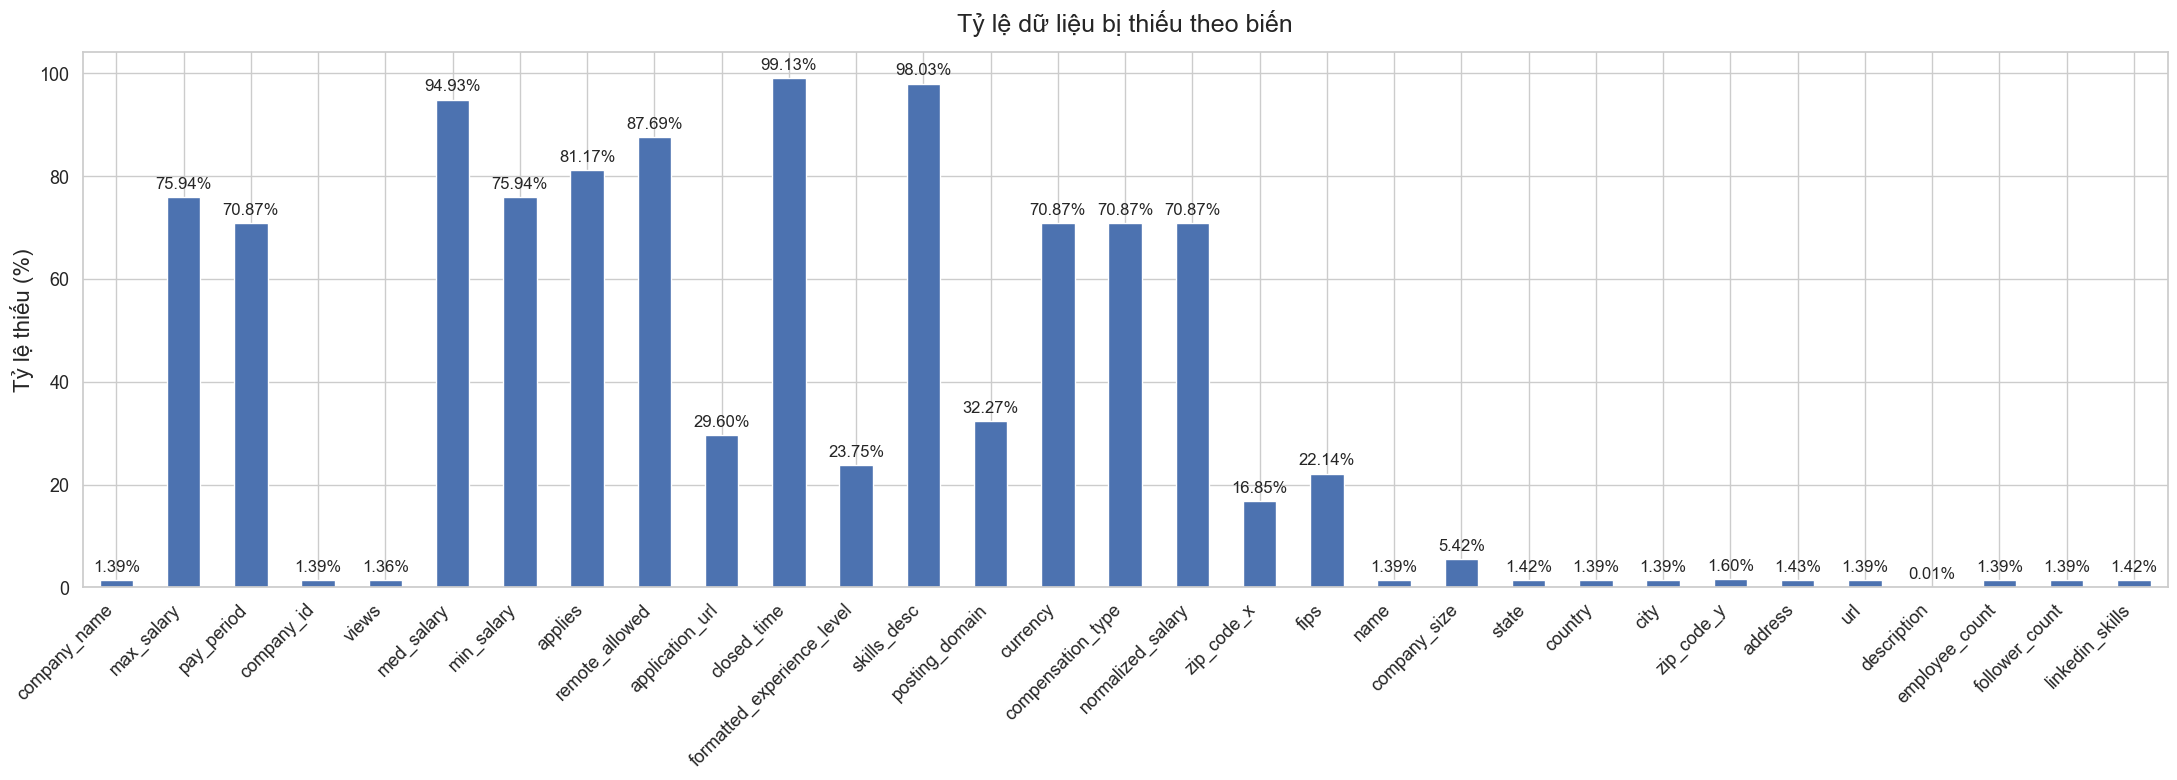

In [19]:
# tính missing
missing_percent = job_merged.isnull().mean() * 100
missing_count = job_merged.isnull().sum()
cols_with_missing = missing_count[missing_count > 0].index

# tạo figure + axis
fig, ax = plt.subplots(figsize=(22, 8))

# vẽ bar chart
missing_percent[cols_with_missing].plot(kind="bar", ax=ax)

# label & title (TĂNG FONT)
ax.set_ylabel("Tỷ lệ thiếu (%)", fontsize=16)
ax.set_title("Tỷ lệ dữ liệu bị thiếu theo biến", fontsize=18, pad=15)

# trục x (TĂNG FONT)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=13)

# trục y (TĂNG FONT)
ax.tick_params(axis="y", labelsize=13)

# thêm giá trị lên mỗi cột (TĂNG FONT)
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f"{height:.2f}%",
        (p.get_x() + p.get_width() / 2, height),
        ha="center",
        va="bottom",
        fontsize=12,
        xytext=(0, 4),
        textcoords="offset points",
    )

plt.tight_layout()
plt.show()


## 2.2 Tiền xử lí dữ liệu

In [20]:
for col in ["country", "state", "city"]:
    if col in job_merged.columns:
        job_merged[col] = job_merged[col].replace("0", np.nan)
        job_merged[col] = job_merged[col].fillna("Unknown")

# ép kiểu rõ ràng
numeric_cols = [
    "min_salary",
    "med_salary",
    "max_salary",
    "normalized_salary",
    "views",
    "applies",
    "employee_count",
    "follower_count",
]

for col in numeric_cols:
    if col in job_merged.columns:
        job_merged[col] = pd.to_numeric(job_merged[col], errors="coerce")

job_merged["description"] = job_merged["description"].fillna("")

# số lượng kí tự
job_merged["desc_len"] = job_merged["description"].str.len()

job_merged["salary_annual"] = job_merged["normalized_salary"]

# ưu tiên normalized_salary, nếu không có thì dùng med_salary
job_merged.loc[job_merged["salary_annual"].isna(), "salary_annual"] = job_merged[
    "med_salary"
]

# Loại giá trị bất hợp lý
job_merged.loc[
    (job_merged["salary_annual"] < 10_000) | (job_merged["salary_annual"] > 500_000),
    "salary_annual",
] = np.nan

# log-transform
job_merged["log_salary"] = np.log1p(job_merged["salary_annual"])

# tạo cột mới chuẩn hóa description
job_merged["description_norm"] = (
    job_merged["description"].fillna("").apply(normalize_text)
)


def extract_seniority(title: str) -> str:
    if pd.isna(title):
        return "normal"
    t = str(title).lower()
    # bạn có thể mở rộng thêm keyword
    if re.search(r"\b(intern|internship|trainee)\b", t):
        return "intern"
    if re.search(r"\b(junior|jr\.?)\b", t):
        return "junior"
    if re.search(r"\b(senior|sr\.?)\b", t):
        return "senior"
    if re.search(r"\b(lead|principal|staff)\b", t):
        return "lead"
    if re.search(r"\b(manager|head)\b", t):
        return "manager"
    if re.search(r"\b(director|vp|vice president)\b", t):
        return "director"
    if re.search(r"\b(c-level|cto|cfo|ceo|chief)\b", t):
        return "executive"
    return "normal"


job_merged["seniority"] = job_merged["title"].apply(extract_seniority)


In [21]:
job_merged.describe()

,job_id,max_salary,company_id,views,med_salary,min_salary,applies,original_listed_time,remote_allowed,expiry,...,sponsored,normalized_salary,zip_code_x,fips,company_size,employee_count,follower_count,desc_len,salary_annual,log_salary
count,1.238490e+05,2.979300e+04,1.221320e+05,122160.000000,6280.000000,2.979300e+04,23320.000000,1.238490e+05,15246.0,1.238490e+05,...,123849.0,3.607300e+04,102977.000000,96434.000000,117142.000000,122131.000000,1.221310e+05,123849.000000,35560.000000,35560.000000
mean,3.896402e+09,9.193942e+04,1.220401e+07,14.618247,22015.619876,6.491085e+04,10.591981,1.713152e+12,1.0,1.716213e+12,...,0.0,2.053270e+05,50400.491887,28713.879887,4.935420,17452.960444,5.029376e+05,3766.251322,95692.286290,11.313366
std,8.404355e+07,7.011101e+05,2.554143e+07,85.903598,52255.873846,4.959738e+05,29.047395,4.848209e+08,0.0,2.321394e+09,...,0.0,5.097627e+06,30252.232515,16015.929825,2.054749,59150.405648,2.297005e+06,2146.618664,56534.379006,0.557926
min,9.217160e+05,1.000000e+00,1.009000e+03,1.000000,0.000000,1.000000e+00,1.000000,1.701811e+12,1.0,1.712903e+12,...,0.0,0.000000e+00,1001.000000,1003.000000,1.000000,0.000000,0.000000e+00,0.000000,10000.000000,9.210440
25%,3.894587e+09,4.828000e+01,1.435200e+04,3.000000,18.940000,3.700000e+01,1.000000,1.712863e+12,1.0,1.715481e+12,...,0.0,5.200000e+04,24112.000000,13121.000000,3.000000,188.000000,1.207800e+04,2176.000000,52000.000000,10.859018
50%,3.901998e+09,8.000000e+04,2.269650e+05,4.000000,25.500000,6.000000e+04,3.000000,1.713395e+12,1.0,1.716042e+12,...,0.0,8.150000e+04,48059.000000,29183.000000,5.000000,1686.000000,5.334400e+04,3435.000000,82500.000000,11.320566
75%,3.904707e+09,1.400000e+05,8.047188e+06,8.000000,2510.500000,1.000000e+05,8.000000,1.713478e+12,1.0,1.716088e+12,...,0.0,1.250000e+05,78201.000000,42077.000000,7.000000,11289.000000,2.110300e+05,4986.000000,125000.000000,11.736077
max,3.906267e+09,1.200000e+08,1.034730e+08,9975.000000,750000.000000,8.500000e+07,967.000000,1.713573e+12,1.0,1.729125e+12,...,0.0,5.356000e+08,99901.000000,56045.000000,7.000000,748312.000000,3.270284e+07,23201.000000,500000.000000,13.122365


## 2.3 Trực quan hóa dữ liệu

### 2.3.1 Phân bố job theo country (top 10)

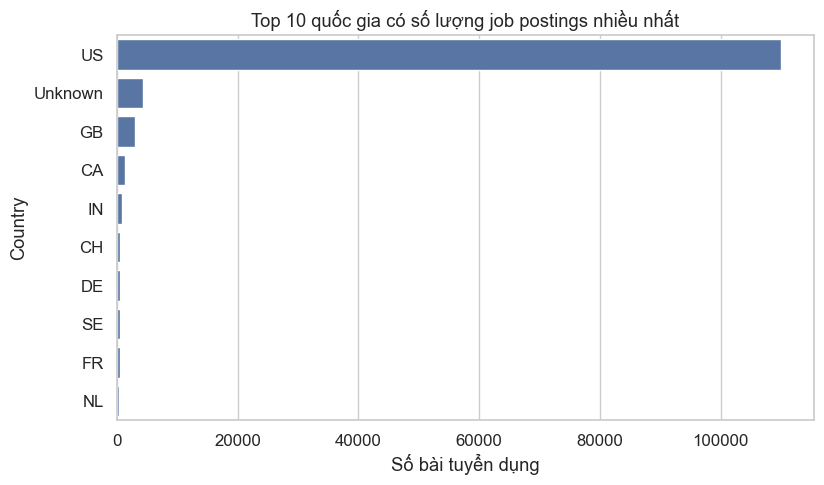

In [22]:
top_countries = job_merged["country"].value_counts().head(10)
plt.figure(figsize=(9, 5))
sns.barplot(x=top_countries.values, y=top_countries.index)
plt.xlabel("Số bài tuyển dụng")
plt.ylabel("Country")
plt.title("Top 10 quốc gia có số lượng job postings nhiều nhất")
plt.show()

### 2.3.2 Phân phối độ dài mô tả công việc

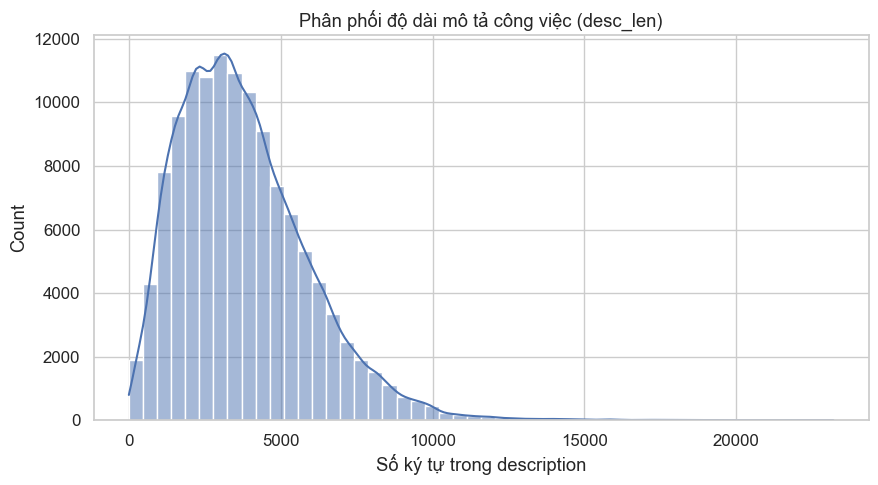

In [23]:
sns.histplot(job_merged["desc_len"], bins=50, kde=True)
plt.xlabel("Số ký tự trong description")
plt.title("Phân phối độ dài mô tả công việc (desc_len)")
plt.show()

### 2.3.3 Biểu đồ phân phối lương

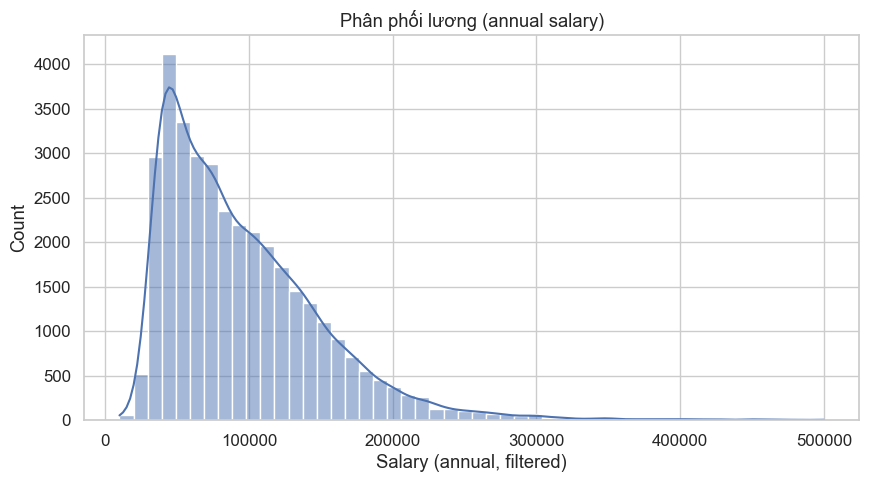

In [24]:
sns.histplot(job_merged["salary_annual"], bins=50, kde=True)
plt.xlabel("Salary (annual, filtered)")
plt.title("Phân phối lương (annual salary)")
plt.show()

### 2.3.4 Biểu đồ so sánh lương theo cấp độ kinh nghiệm

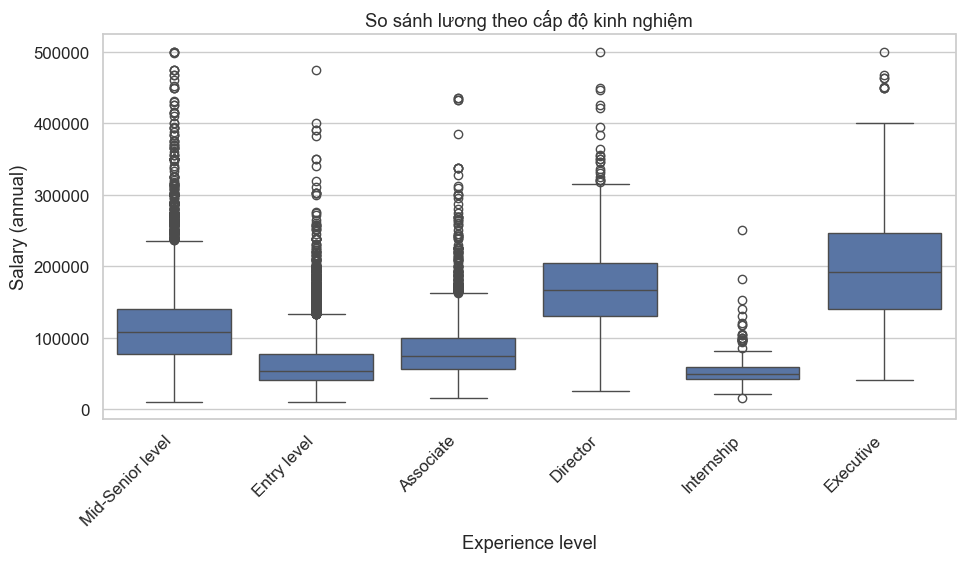

In [25]:
order = job_merged["formatted_experience_level"].value_counts().index.tolist()
plt.figure(figsize=(11, 5))
sns.boxplot(
    data=job_merged, x="formatted_experience_level", y="salary_annual", order=order
)
plt.xticks(rotation=45, ha="right")
plt.xlabel("Experience level")
plt.ylabel("Salary (annual)")
plt.title("So sánh lương theo cấp độ kinh nghiệm")
plt.show()

### 2.3.5 Biểu đồ so sánh lương theo remote_allowed

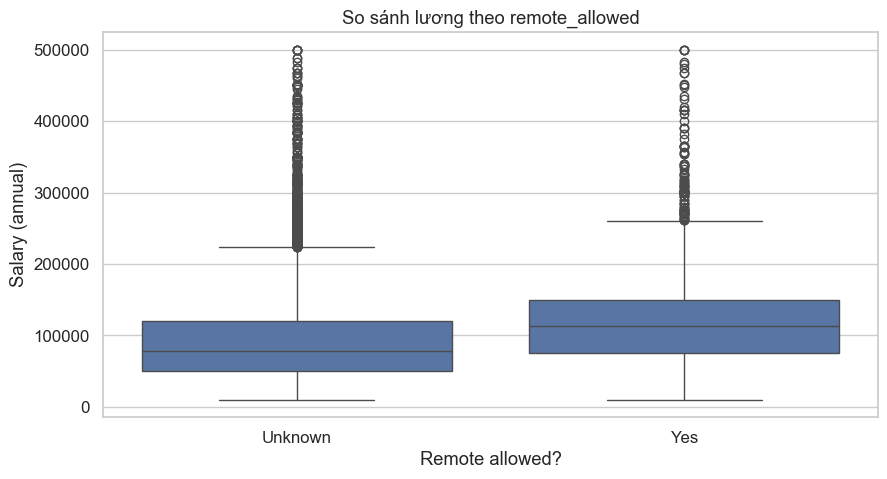

In [26]:
# remote_allowed đôi khi là float/NaN -> đưa về 0/1/Unknown
tmp = job_merged.copy()
tmp["remote_allowed_clean"] = (
    tmp["remote_allowed"]
    .fillna(-1)
    .astype(int)
    .replace({-1: "Unknown", 0: "No", 1: "Yes"})
)
sns.boxplot(data=tmp, x="remote_allowed_clean", y="salary_annual")
plt.xlabel("Remote allowed?")
plt.ylabel("Salary (annual)")
plt.title("So sánh lương theo remote_allowed")
plt.show()

### 2.3.6 Biểu đồ so sánh lương theo quy mô công ty

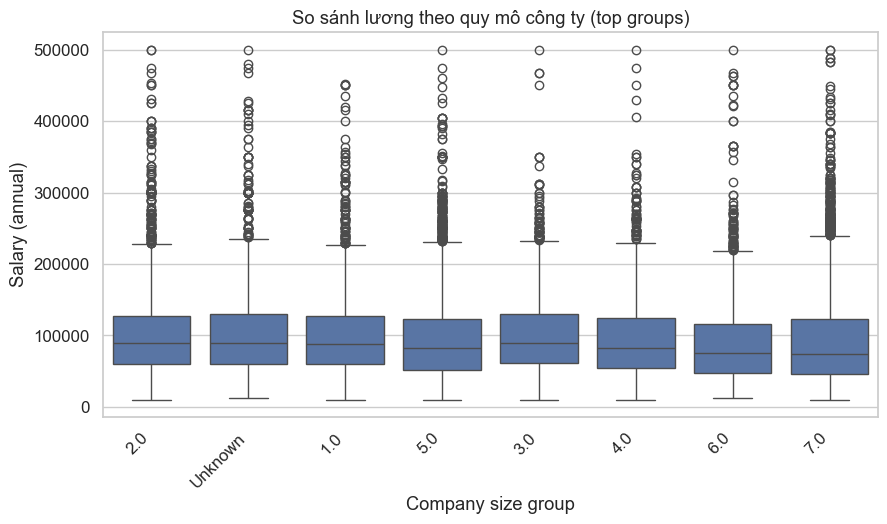

In [27]:
tmp = job_merged.copy()
tmp["company_size"] = tmp["company_size"].fillna("Unknown")
# chỉ lấy top nhóm để dễ nhìn
top_sizes = tmp["company_size"].value_counts().head(8).index
tmp = tmp[tmp["company_size"].isin(top_sizes)]
sns.boxplot(data=tmp, x="company_size", y="salary_annual")
plt.xticks(rotation=45, ha="right")
plt.xlabel("Company size group")
plt.ylabel("Salary (annual)")
plt.title("So sánh lương theo quy mô công ty (top groups)")
plt.show()

### 2.3.7 Biểu đồ mối quan hệ giữa lượt xem và lượt ứng tuyển

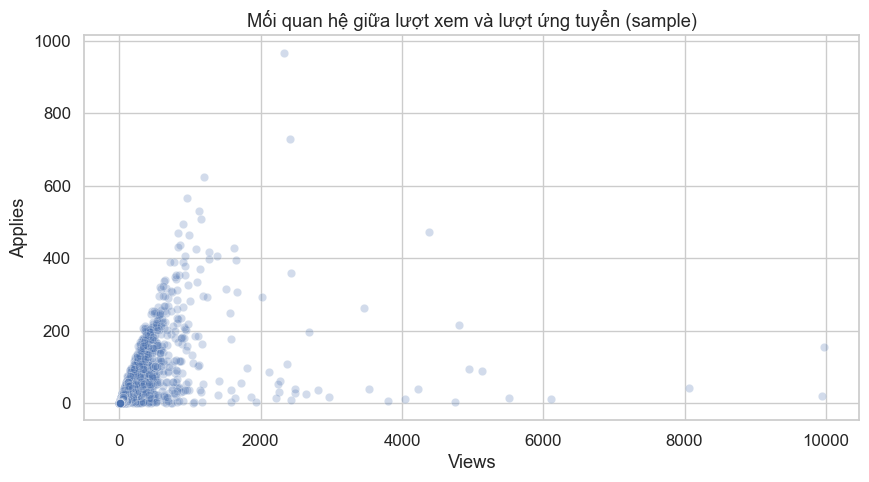

In [28]:
tmp = job_merged[["views", "applies"]].dropna().copy()
tmp = tmp[(tmp["views"] >= 0) & (tmp["applies"] >= 0)]

sns.scatterplot(data=tmp, x="views", y="applies", alpha=0.25)
plt.xlabel("Views")
plt.ylabel("Applies")
plt.title("Mối quan hệ giữa lượt xem và lượt ứng tuyển (sample)")
plt.show()

# 3. RQ1 – Phân cụm 

## 3.1 Chuẩn bị dữ liệu

In [29]:
TEXT_COL = "description_norm"
job_text = job_merged[["job_id", "title", TEXT_COL]].dropna(subset=[TEXT_COL]).copy()

# Sample để chạy nhanh (tuỳ RAM/CPU)
MAX_DOCS = 20000
if len(job_text) > MAX_DOCS:
    job_text_sample = job_text.sample(MAX_DOCS, random_state=42).reset_index(drop=True)
else:
    job_text_sample = job_text.reset_index(drop=True)

print("Số JD dùng cho RQ1 clustering:", len(job_text_sample))

Số JD dùng cho RQ1 clustering: 20000


## 3.2 TF-IDF vectorization (themes)

Trong bước này, mô tả công việc (`description`) được chuyển đổi từ dữ liệu văn bản thô sang dạng vector số bằng phương pháp **TF-IDF (Term Frequency – Inverse Document Frequency)**. TF-IDF giúp đo lường mức độ quan trọng của một từ trong một tài liệu so với toàn bộ tập dữ liệu, qua đó giảm ảnh hưởng của các từ quá phổ biến và làm nổi bật các thuật ngữ mang tính phân biệt nội dung.

Các tham số chính được thiết lập như sau:

* **`stop_words="english"`**: loại bỏ các từ dừng tiếng Anh (ví dụ: *the, and, is*), vốn không mang nhiều ý nghĩa phân biệt nội dung.
* **`max_features=30000`**: giới hạn số lượng đặc trưng TF-IDF tối đa nhằm kiểm soát kích thước không gian đặc trưng và chi phí tính toán.
* **`ngram_range=(1, 2)`**: sử dụng cả unigram và bigram để nắm bắt không chỉ các từ đơn lẻ mà còn các cụm từ ngắn thường xuất hiện trong mô tả công việc (ví dụ: *project management*, *data analysis*).
* **`min_df=10`**: loại bỏ các từ/cụm từ xuất hiện quá ít (dưới 10 tài liệu), giúp giảm nhiễu và các thuật ngữ không đại diện.
* **`max_df=0.80`**: loại bỏ các từ xuất hiện trong hơn 80% số tài liệu, thường là các từ mang tính khuôn mẫu hoặc boilerplate trong mô tả tuyển dụng.

Kết quả của bước này là một **ma trận TF-IDF thưa (sparse matrix)** với kích thước `(số lượng job descriptions, số lượng đặc trưng TF-IDF)`. Ma trận này đóng vai trò là đầu vào cho các thuật toán phân cụm trong RQ1, giúp khám phá các nhóm nội dung (job description themes) tiềm ẩn mà không cần sử dụng bất kỳ nhãn nghề nghiệp hay kỹ năng có sẵn nào.

In [30]:
tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=30000,
    ngram_range=(1, 2),
    min_df=10,  # bỏ từ quá hiếm
    max_df=0.80,  # bỏ từ quá phổ biến (boilerplate)
)
X = tfidf.fit_transform(job_text_sample[TEXT_COL])
print("TF-IDF matrix:", X.shape)

TF-IDF matrix: (20000, 30000)


## 3.3 Chạy K-Means

In [31]:
SIL_SAMPLE = 10000
if X.shape[0] > SIL_SAMPLE:
    rng = np.random.RandomState(42)
    idx_sil = rng.choice(X.shape[0], size=SIL_SAMPLE, replace=False)
    X_sil = X[idx_sil]
else:
    X_sil = X

In [32]:
kmeans = KMeans(n_clusters=15, random_state=42, n_init=10)
job_text_sample["cluster"] = kmeans.fit_predict(X)

## 3.4 Tìm Top keywords

In [41]:
def top_terms_per_cluster(model, vectorizer, n_terms=15):
    terms = np.array(vectorizer.get_feature_names_out())
    order_centroids = model.cluster_centers_.argsort()[:, ::-1]
    cluster_terms = {}
    for i in range(model.n_clusters):
        cluster_terms[i] = terms[order_centroids[i, :n_terms]]
    return cluster_terms


cluster_keywords = top_terms_per_cluster(kmeans, tfidf, n_terms=15)

print("\nTop keywords per cluster:")
for cid, kws in cluster_keywords.items():
    print(f"Cluster {cid}: {', '.join(kws[:15])}")


Top keywords per cluster:
Cluster 0: data, software, cloud, security, design, technical, development, business, systems, solutions, sql, skills, team, engineering, management
Cluster 1: accounting, financial, tax, finance, reporting, accounts, accountant, monthly, analysis, degree accounting, cpa, payable, business, statements, management
Cluster 2: equipment, safety, required, job, ability, perform, duties, company, employee, able, essential, customer, warehouse, service, functions
Cluster 3: engineering, manufacturing, equipment, maintenance, electrical, production, quality, design, mechanical, systems, safety, technical, process, skf, product
Cluster 4: store, customer, sales, merchandise, customers, retail, store manager, service, manager, associates, customer service, associate, team, company, merchandising
Cluster 5: sales, customer, business, customers, new, team, account, territory, market, company, product, marketing, relationships, products, skills
Cluster 6: status, busines

**Nhận xét**

Kết quả phân cụm với **k = 15** cho thấy các mô tả công việc trên LinkedIn đã **tự nhiên hình thành những nhóm nội dung (job description themes)** khác nhau, ngay cả khi không sử dụng bất kỳ nhãn nghề nghiệp hay ngành nghề có sẵn nào. Mỗi cụm được đặc trưng bởi tập từ khóa TF-IDF có tính đại diện cao, phản ánh bản chất nội dung công việc.

Dựa trên các từ khóa tiêu biểu, các cluster có thể được **gộp thành các meta-theme nội dung** như sau:

---

### **Meta-theme 1: Công nghệ thông tin – Phát triển phần mềm – Dữ liệu**

**Clusters tiêu biểu:** 0, 10, 11, 13

* **Cluster 0:** *data, software, cloud, security, sql, engineering*
* **Cluster 10:** *project, construction, engineering, project management* (thiên về IT/technical projects)
* **Cluster 11:** *network, ip, customer support, policy, covid* (IT/network infrastructure)
* **Cluster 13:** *service, skills, customer, support, management*

 Các cụm này phản ánh **chủ đề nội dung công việc liên quan đến công nghệ**, bao gồm phát triển phần mềm, dữ liệu, hệ thống mạng, quản lý dự án kỹ thuật và hỗ trợ kỹ thuật. Điều này cho thấy IT là một **chủ đề nội dung xuyên ngành**, không bị giới hạn trong một ngành nghề duy nhất.

---

### **Meta-theme 2: Tài chính – Kế toán – Kinh doanh chuyên môn**

**Clusters tiêu biểu:** 1, 7

* **Cluster 1:** *accounting, financial, tax, reporting, CPA*
* **Cluster 7:** *earnings, credit, business owners, executive consultants*

 Các cluster này có nội dung JD tập trung vào **nghiệp vụ tài chính, kế toán và kinh doanh cấp cao**, phản ánh các vai trò chuyên môn và quản lý tài chính.

---

### **Meta-theme 3: Sản xuất – Kỹ thuật – Bảo trì – Công nghiệp**

**Clusters tiêu biểu:** 2, 3

* **Cluster 2:** *equipment, safety, warehouse, duties, service*
* **Cluster 3:** *manufacturing, maintenance, electrical, mechanical, production*

 Đây là các cụm thể hiện **chủ đề công việc kỹ thuật – vận hành – sản xuất**, với nội dung JD nhấn mạnh vào an toàn, bảo trì, vận hành thiết bị và quy trình sản xuất.

---

### **Meta-theme 4: Bán lẻ – Bán hàng – Chăm sóc khách hàng**

**Clusters tiêu biểu:** 4, 5

* **Cluster 4:** *store, retail, merchandise, customer service*
* **Cluster 5:** *sales, account, territory, relationships, products*

Các cluster này đại diện cho **chủ đề dịch vụ và bán hàng**, từ bán lẻ tại cửa hàng đến bán hàng B2B và quản lý khách hàng.

---

### **Meta-theme 5: Nhân sự – Hành chính – Tuân thủ**

**Cluster tiêu biểu:** 6

* **Cluster 6:** *employment, benefits, gender, disability, protected*

Cụm này phản ánh **nội dung JD liên quan đến chính sách nhân sự, phúc lợi và tuân thủ pháp lý**, thường xuất hiện trong phần boilerplate của mô tả công việc.

---

### **Meta-theme 6: Giáo dục – Cộng đồng – Dịch vụ xã hội**

**Cluster tiêu biểu:** 9

* **Cluster 9:** *students, school, education, teaching, community*

Thể hiện **chủ đề nội dung giáo dục và dịch vụ cộng đồng**, tách biệt rõ ràng với các lĩnh vực khác.

---

### **Meta-theme 7: Y tế – Chăm sóc sức khỏe**

**Clusters tiêu biểu:** 8, 14

* **Cluster 8:** *nursing, registered nurse, healthcare staffing*
* **Cluster 14:** *patient care, hospital, clinical, physician*

 Hai cluster này phản ánh **hai khía cạnh khác nhau của lĩnh vực y tế**: một bên thiên về **nhân sự điều dưỡng/agency**, bên còn lại thiên về **chăm sóc lâm sàng và bệnh viện**.

---

## 3.5 Biểu đồ phân bố số lượng JD theo cluster

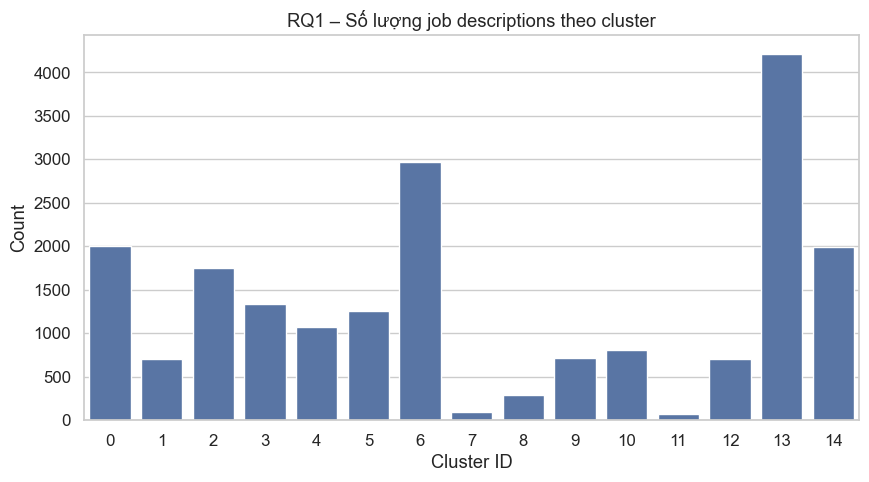

In [34]:
counts = job_text_sample["cluster"].value_counts().sort_index()
sns.barplot(x=counts.index, y=counts.values)
plt.title("RQ1 – Số lượng job descriptions theo cluster")
plt.xlabel("Cluster ID")
plt.ylabel("Count")
plt.show()

## 3.6 Trực quan hóa t-SNE

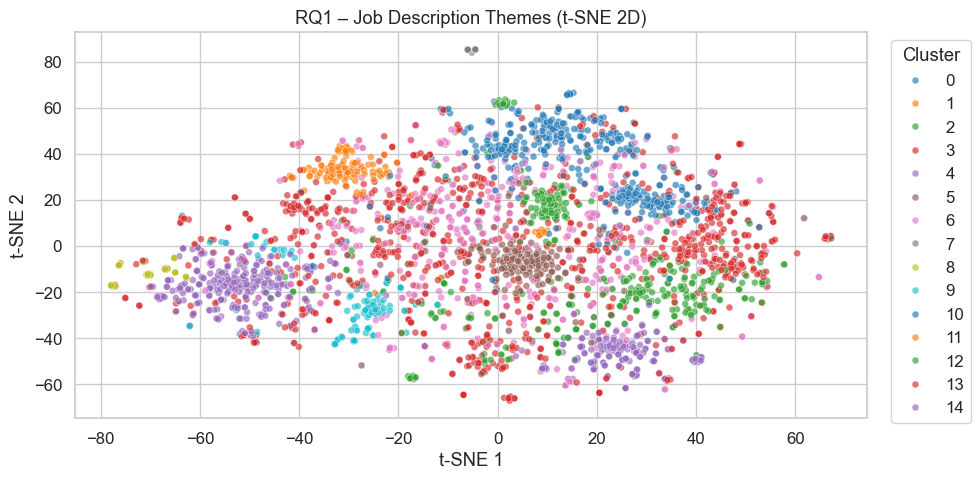

In [35]:
# t-SNE cần dense nên phải sample nhỏ
VIS_N = 3000
if X.shape[0] > VIS_N:
    job_vis = job_text_sample.sample(VIS_N, random_state=42).reset_index(drop=True)
    # Lưu ý: vì reset_index nên X phải lấy theo index của job_vis trước reset
    # Cách đơn giản: sample index từ job_text_sample trước, rồi dùng index đó lấy X
    idx_vis = job_text_sample.sample(VIS_N, random_state=42).index
    job_vis = job_text_sample.loc[idx_vis].reset_index(drop=True)
    X_vis = X[idx_vis]
else:
    job_vis = job_text_sample.copy()
    X_vis = X

tsne = TSNE(
    n_components=2, perplexity=40, learning_rate=200, init="pca", random_state=42
)
X_tsne = tsne.fit_transform(X_vis.toarray())

job_vis["tsne1"] = X_tsne[:, 0]
job_vis["tsne2"] = X_tsne[:, 1]

sns.scatterplot(
    data=job_vis, x="tsne1", y="tsne2", hue="cluster", palette="tab10", alpha=0.65, s=25
)
plt.title("RQ1 – Job Description Themes (t-SNE 2D)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

**Nhận xét biểu đồ t-SNE**

Biểu đồ t-SNE cho thấy các mô tả công việc được phân cụm thành nhiều nhóm nội dung khác nhau trong không gian 2 chiều. Mặc dù vẫn tồn tại sự chồng lấn giữa một số cụm, đặc biệt ở khu vực trung tâm, nhiều cụm thể hiện sự tập trung tương đối rõ ràng, cho thấy các mô tả công việc có xu hướng chia sẻ những chủ đề nội dung chung. Điều này phản ánh bản chất liên ngành của thị trường lao động, nơi các vai trò công việc có thể chia sẻ từ vựng và yêu cầu tương tự. Kết quả trực quan hóa này hỗ trợ giả thuyết của RQ1 rằng các mô tả công việc có thể hình thành các chủ đề nội dung tiềm ẩn (job description themes) ngay cả khi không sử dụng nhãn nghề nghiệp hoặc kỹ năng có sẵn.

## 3.7 Đánh giá hậu nghiệm

In [37]:

# ==== Load industries tables ====
JOB_INDUSTRIES_PATH = "../data/job_industries.csv"
INDUSTRIES_PATH     = "../data/industries.csv"

job_industries_df = pd.read_csv(JOB_INDUSTRIES_PATH)   # job_id, industry_id
industries_df     = pd.read_csv(INDUSTRIES_PATH)       # industry_id, industry_name

# ==== Join để lấy industry_name cho mỗi job ====
job_ind_full = job_industries_df.merge(
    industries_df, on="industry_id", how="left"
)

# job_text_sample MUST have: job_id, cluster
assert "job_id" in job_text_sample.columns, "job_text_sample thiếu cột job_id"
assert "cluster" in job_text_sample.columns, "job_text_sample thiếu cột cluster (chạy KMeans trước)"

cluster_ind_df = (
    job_text_sample[["job_id", "cluster"]]
    .merge(job_ind_full[["job_id", "industry_name"]], on="job_id", how="left")
)

cluster_ind_df["industry_name"] = cluster_ind_df["industry_name"].fillna("Unknown")
cluster_ind_df.head()


,job_id,cluster,industry_name
0,3902944011,3,Oil and Gas
1,3901960222,13,Telecommunications
2,3900944095,2,Manufacturing
3,3903878594,13,Broadcast Media Production and Distribution
4,3905670593,14,Hospitals and Health Care


In [38]:

cluster_industry_dist = (
    cluster_ind_df
    .groupby(["cluster", "industry_name"])
    .size()
    .reset_index(name="count")
    .sort_values(["cluster", "count"], ascending=[True, False])
)

TOP_N = 5
top_ind_by_cluster = cluster_industry_dist.groupby("cluster").head(TOP_N)
top_ind_by_cluster.head(30)


,cluster,industry_name,count
68,0,IT Services and IT Consulting,646
136,0,Software Development,308
51,0,Financial Services,151
142,0,Staffing and Recruiting,102
78,0,Information Services,78
164,1,Accounting,170
210,1,Financial Services,80
281,1,Staffing and Recruiting,71
240,1,Manufacturing,48
265,1,Real Estate,34


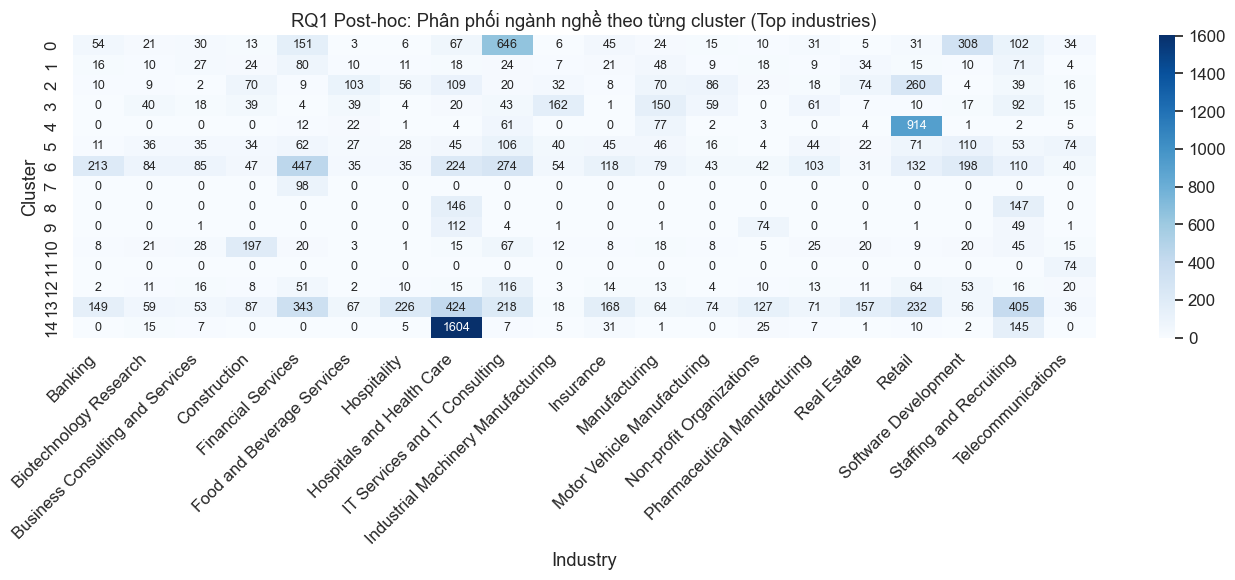

In [39]:

TOP_INDUSTRIES = 20
top_industries = (
    cluster_industry_dist.groupby("industry_name")["count"].sum()
    .sort_values(ascending=False)
    .head(TOP_INDUSTRIES)
    .index
)

heat_df = cluster_industry_dist[cluster_industry_dist["industry_name"].isin(top_industries)]

pivot = heat_df.pivot_table(
    index="cluster",
    columns="industry_name",
    values="count",
    aggfunc="sum",
    fill_value=0
)

plt.figure(figsize=(14, 6))
sns.heatmap(
    pivot,
    cmap="Blues",
    annot=True,          # HIỆN SỐ
    fmt=".0f",           # số nguyên
    annot_kws={"size": 9}
)
plt.xticks(rotation=45, ha="right")
plt.title("RQ1 Post-hoc: Phân phối ngành nghề theo từng cluster (Top industries)")
plt.xlabel("Industry")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()


**Nhận xét**

Biểu đồ heatmap thể hiện **phân phối số lượng tin tuyển dụng theo từng cluster nội dung (trục dọc)** và **ngành nghề chính thức của LinkedIn (trục ngang)**. Việc kết hợp biểu đồ này với **từ khóa đặc trưng của từng cluster** cho phép đánh giá mức độ **phù hợp và ý nghĩa thực tiễn** của các chủ đề nội dung được phát hiện.

### 1. Meta-theme 1: Công nghệ thông tin – Phát triển phần mềm – Dữ liệu

*(Clusters 0, 10, 11, 13)*

Các cluster thuộc meta-theme này cho thấy **sự tập trung cao vào các ngành IT Services and IT Consulting, Software Development, và Staffing & Recruiting**.

* **Cluster 0** có số lượng lớn trong *IT Services and IT Consulting (646)* và *Software Development (308)*, hoàn toàn phù hợp với các từ khóa như *data, software, cloud, security*.
* **Cluster 13** phân bố mạnh ở *Hospitals and Health Care (424)*, *Financial Services (343)* và *Staffing and Recruiting (405)*, phản ánh thực tế rằng **vai trò IT, hỗ trợ kỹ thuật và dịch vụ khách hàng công nghệ xuất hiện rộng khắp nhiều ngành**, không chỉ giới hạn trong ngành CNTT thuần túy.
* **Cluster 11** tuy có quy mô nhỏ hơn nhưng tập trung vào *Telecommunications*, phù hợp với các từ khóa liên quan đến *network, IP, infrastructure*.

 Điều này củng cố luận điểm rằng **CNTT là một chủ đề nội dung xuyên ngành**, và phân cụm đang phản ánh *cấu trúc nội dung công việc*, không chỉ đơn thuần là phân loại ngành.

---

### 2. Meta-theme 2: Tài chính – Kế toán – Kinh doanh chuyên môn

*(Clusters 1, 7)*

* **Cluster 1** phân bố rõ rệt trong *Financial Services (80)*, *Accounting-related industries*, và *Insurance*, phù hợp với từ khóa *accounting, tax, reporting, CPA*.
* **Cluster 7** tuy quy mô nhỏ nhưng tập trung vào *Financial Services (98)*, phản ánh các vai trò kinh doanh và tư vấn cấp cao.

 Meta-theme này cho thấy **nội dung JD mang tính nghiệp vụ tài chính cao có sự đồng nhất mạnh mẽ với ngành nghề chính thức**, cho thấy cấu trúc nội dung rõ ràng và ít giao thoa.

---

### 3. Meta-theme 3: Sản xuất – Kỹ thuật – Bảo trì – Công nghiệp

*(Clusters 2, 3)*

* **Cluster 3** nổi bật ở *Industrial Machinery Manufacturing (162)* và *Manufacturing (150)*, khớp chặt chẽ với các từ khóa *manufacturing, maintenance, mechanical, electrical*.
* **Cluster 2** phân bố rộng hơn, xuất hiện cả trong *Retail (260)* và *Construction (70)*, phản ánh các vai trò vận hành, kho bãi và kỹ thuật hỗ trợ.

 Điều này cho thấy **cùng một chủ đề nội dung kỹ thuật có thể được triển khai trong nhiều ngành**, tùy vào bối cảnh tổ chức.

---

### 4. Meta-theme 4: Bán lẻ – Bán hàng – Chăm sóc khách hàng

*(Clusters 4, 5)*

* **Cluster 4** có sự tập trung rất mạnh vào *Retail (914)*, hoàn toàn phù hợp với các từ khóa *store, retail, merchandise, customer service*.
* **Cluster 5** phân bố đều hơn giữa *Retail*, *Business Services* và *Software Development*, phản ánh các vai trò bán hàng B2B và quản lý khách hàng.

 Meta-theme này thể hiện **mối quan hệ chặt giữa nội dung công việc và ngành bán lẻ/dịch vụ**, đồng thời cho thấy sự chuyển dịch từ bán lẻ truyền thống sang bán hàng đa kênh.

---

### 5. Meta-theme 5: Nhân sự – Hành chính – Tuân thủ

*(Cluster 6)*

* **Cluster 6** xuất hiện nhiều trong *Financial Services (447)*, *IT Services (274)* và *Hospitals and Health Care (224)*.
* Các từ khóa như *employment, benefits, protected* cho thấy đây là **nội dung boilerplate nhân sự**, thường được lặp lại trong mô tả công việc của nhiều ngành khác nhau.

 Điều này giải thích vì sao cluster này **không gắn chặt với một ngành cụ thể**, mà phản ánh một **lớp nội dung chuẩn hóa xuyên ngành**.

---

### 6. Meta-theme 6: Giáo dục – Cộng đồng – Dịch vụ xã hội

*(Cluster 9)*

* **Cluster 9** tập trung vào *Non-profit Organizations (74)* và *Hospitals and Health Care (112)*, phù hợp với các từ khóa *students, school, community, education*.

 Đây là một meta-theme có **ranh giới rõ ràng**, phản ánh các vai trò giáo dục và dịch vụ xã hội tách biệt với khu vực doanh nghiệp.

---

### 7. Meta-theme 7: Y tế – Chăm sóc sức khỏe

*(Clusters 8, 14)*

* **Cluster 14** có phân bố cực kỳ mạnh ở *Hospitals and Health Care (1604)*, là minh chứng rõ ràng nhất cho một **chủ đề nội dung y tế thuần túy**.
* **Cluster 8** cũng tập trung vào *Healthcare Staffing*, phản ánh các vai trò điều dưỡng và nhân sự y tế.

 Meta-theme này cho thấy **phân cụm đã tái tạo rất tốt cấu trúc nội dung ngành y**, với mức độ nhất quán cao giữa nội dung JD và ngành nghề chính thức.

## 3.8 Kết luận

Kết quả nghiên cứu cho RQ1 cho thấy các mô tả công việc trên LinkedIn **có xu hướng tự nhiên hình thành những nhóm nội dung (job description themes) rõ ràng**, ngay cả khi **không sử dụng bất kỳ nhãn nghề nghiệp, ngành nghề hay kỹ năng có sẵn nào**. Thông qua việc phân cụm mô tả công việc dựa trên biểu diễn TF-IDF và thuật toán K-means, nghiên cứu đã phát hiện các cluster có tính nhất quán cao về mặt ngữ nghĩa, phản ánh những chủ đề nội dung đặc trưng của công việc.

Phân tích từ khóa đại diện cho từng cluster cho thấy các nhóm này không chỉ tái hiện những lĩnh vực quen thuộc như công nghệ thông tin, tài chính – kế toán, sản xuất – kỹ thuật, bán lẻ, giáo dục hay y tế, mà còn làm nổi bật các lớp nội dung mang tính chức năng xuyên ngành, chẳng hạn như nội dung nhân sự – tuân thủ hoặc hỗ trợ kỹ thuật. Kết quả hậu nghiệm khi đối chiếu với phân loại ngành nghề chính thức của LinkedIn cho thấy các cluster nội dung **vừa có sự tương đồng với ngành nghề, vừa không bị ràng buộc hoàn toàn bởi chúng**, phản ánh đúng bản chất đa chiều của mô tả công việc trong thực tế.

Việc tổng hợp các cluster thành 7 meta-theme nội dung đã giúp làm rõ **cấu trúc tiềm ẩn của thị trường lao động**, trong đó mô tả công việc được tổ chức theo **chức năng, vai trò và nội dung công việc** hơn là theo nhãn ngành truyền thống. Điều này khẳng định rằng phân cụm mô tả công việc là một hướng tiếp cận có ý nghĩa, bổ sung cho các hệ thống phân loại sẵn có, đồng thời cung cấp góc nhìn sâu hơn về cách thị trường lao động được biểu hiện qua ngôn ngữ tuyển dụng.

Tóm lại, RQ1 được trả lời một cách thuyết phục: **mô tả công việc trên LinkedIn thực sự chứa đựng các cấu trúc nội dung tiềm ẩn có thể được khám phá bằng các phương pháp khai phá dữ liệu không giám sát**, và các cấu trúc này mang ý nghĩa thực tiễn rõ ràng đối với phân tích thị trường lao động.

# 4. RQ2 – Khai phá *Skill Bundles* từ ESCO Ontology

## 4.1. Load & làm sạch ESCO skills (skill_en.csv) 

**Giải thích việc sử dụng ESCO skills trong RQ2**

Trong dữ liệu tuyển dụng LinkedIn, thông tin kỹ năng chủ yếu xuất hiện dưới dạng **văn bản tự do** trong mô tả công việc, không được chuẩn hóa và dễ trùng lặp về cách diễn đạt. Điều này gây khó khăn cho việc khai phá luật kết hợp trực tiếp từ dữ liệu thô.

Để khắc phục, nghiên cứu sử dụng **ESCO skills ontology** như một **từ điển kỹ năng chuẩn**, giúp chuẩn hóa khái niệm “kỹ năng” và giảm nhiễu ngôn ngữ. Các kỹ năng ESCO được đối chiếu với n-gram xuất hiện thực tế trong mô tả công việc, chỉ giữ lại những kỹ năng thực sự có mặt trong dữ liệu tuyển dụng.

Từ đó, mỗi bài tuyển dụng được biểu diễn bằng một tập kỹ năng ESCO, cho phép áp dụng phân tích đồng xuất hiện và khai phá luật kết hợp để phát hiện các **skill bundles** – những nhóm kỹ năng thường được yêu cầu cùng nhau.

Cách tiếp cận này giúp RQ2 khám phá **cấu trúc kỹ năng ẩn của thị trường lao động**, phản ánh nhu cầu thực tế theo từng lĩnh vực nghề nghiệp, thay vì chỉ dựa vào danh sách kỹ năng rời rạc trong dữ liệu gốc.


In [ ]:
ESCO_SKILL_PATH = "data/skills_en.csv"
esco = pd.read_csv(ESCO_SKILL_PATH)
esco_raw = esco["preferredLabel"].dropna().astype(str)
esco_norm = esco_raw.apply(normalize_text)


GENERIC_SKILL_STOP = {
    "work",
    "team",
    "communication",
    "management",
    "business",
    "problem solving",
    "customer service",
    "time management",
    "leadership",
    "planning",
    "organise",
    "organize",
}


def is_valid_skill(term: str) -> bool:
    term = term.strip()
    if len(term) < 3:
        return False
    if term.isdigit():
        return False
    if len(term.split()) > 5:
        return False
    if term in GENERIC_SKILL_STOP:
        return False
    # loại cụm quá “động từ chung chung”
    if re.match(r"^(manage|assist|support|help|work|perform|provide)\b", term):
        return False
    return True


esco_clean = esco_norm[esco_norm.apply(is_valid_skill)].drop_duplicates()
esco_skills = esco_clean.tolist()
print("Số ESCO skills sau khi làm sạch:", len(esco_skills))
esco_skills[:20]

Số ESCO skills sau khi làm sạch: 11180


['supervise correctional procedures',
 'apply anti oppressive practices',
 'identify available services',
 'ensure coquille uniformity',
 'haskell',
 'show initiative',
 'apply diplomatic principles',
 'lead police investigations',
 'handle fish harvesting waste',
 'develop energy saving concepts',
 'sport and exercise medicine',
 'conduct research on flora',
 'install heat pump',
 'design biomass installations',
 'handle equipment while suspended',
 'teach housekeeping skills',
 'check train engines',
 'influence public policies',
 'enterprise risk management',
 'manufacture ingredients']

## 4.2. Vector hóa n-gram từ mô tả công việc

**Khai phá n-gram từ toàn bộ mô tả công việc**

Để phục vụ cho các phân tích ngôn ngữ nâng cao và nhận diện các cụm từ (phrase) phổ biến trong mô tả công việc, chúng tôi tiến hành trích xuất n-gram từ toàn bộ trường *description*. Trước tiên, văn bản được chuẩn hóa thông qua hàm `normalize_text`, nhằm đảm bảo tính nhất quán giữa các mô tả.

Do kích thước dữ liệu lớn, chúng tôi giới hạn tối đa 80.000 dòng khi huấn luyện mô hình n-gram. Việc lấy mẫu này giúp giảm chi phí tính toán nhưng vẫn duy trì được sự đa dạng của ngôn ngữ trong tập dữ liệu.

Quá trình trích xuất n-gram sử dụng **CountVectorizer** với các thiết lập:

- **ngram_range = (1, 4)**: trích xuất unigram, bigram, trigram và four-gram, cho phép phát hiện cả các cụm từ ngữ dài liên quan đến kỹ năng hoặc mô tả nhiệm vụ.
- **min_df = 30**: chỉ giữ lại các n-gram xuất hiện ít nhất 30 lần, giúp loại bỏ nhiễu và từ hiếm.
- **max_df = 0.80**: loại bỏ các n-gram xuất hiện quá phổ biến, tránh các cụm từ ít mang tính phân biệt.
- **token_pattern** được điều chỉnh để cho phép giữ lại các token chứa ký tự số, ký tự đặc biệt như `+` hoặc `#` (ví dụ: *c++*, *c#*, *python3*).
- **stop_words = "english"** nhằm loại bỏ các từ dừng không mang ý nghĩa phân tích.

Sau khi vectorizer được huấn luyện trên mẫu dữ liệu, chúng tôi lấy danh sách toàn bộ n-gram xuất hiện trong tập mô tả công việc và in ra tổng số lượng n-gram thu được. Các n-gram này có thể được sử dụng cho phân tích kỹ năng nâng cao, phát hiện phrase đặc trưng theo cụm hoặc xây dựng từ điển kỹ năng tùy chỉnh.


In [ ]:
# desc_series_full = job_merged["description"].fillna("").apply(normalize_text)
desc_series_full = job_merged["description_norm"]

MAX_ROWS_NGRAM = 80000
if len(desc_series_full) > MAX_ROWS_NGRAM:
    desc_sample = desc_series_full.sample(MAX_ROWS_NGRAM, random_state=42)
else:
    desc_sample = desc_series_full

vec_all = CountVectorizer(
    ngram_range=(1, 4),
    min_df=30,
    max_df=0.75,
    token_pattern=r"[a-z0-9+#]+",
    stop_words="english",
)
vec_all.fit(desc_sample)
ngrams_all = set(vec_all.get_feature_names_out())
print("Tổng số n-gram từ mô tả:", len(ngrams_all))

Tổng số n-gram từ mô tả: 294821


## 4.3. Giao giữa ESCO skills & n-gram trong dữ liệu

In [ ]:
esco_set = set(esco_skills)
skill_vocab = sorted(list(esco_set & ngrams_all))
print("Số ESCO skills thực sự xuất hiện trong corpus:", len(skill_vocab))
skill_vocab[:30]

Số ESCO skills thực sự xuất hiện trong corpus: 545


['abap',
 'accounting',
 'accounting entries',
 'achieve sales targets',
 'actuarial science',
 'acute care',
 'adhesives',
 'adjust priorities',
 'adobe creative suite',
 'adobe illustrator',
 'adobe photoshop',
 'adult education',
 'advanced materials',
 'advocate health',
 'aerospace engineering',
 'aesthetics',
 'agile development',
 'agile project management',
 'ajax',
 'alarm systems',
 'algebra',
 'algorithms',
 'allergies',
 'alternative energy',
 'analytical chemistry',
 'angular',
 'animal nutrition',
 'animal welfare',
 'ansible',
 'answer incoming calls']

## 4.4. Ma trận doc x skill cho toàn bộ job

**Vector hóa kỹ năng ESCO trong mô tả công việc**

Đoạn code trên thực hiện việc **chuyển đổi mô tả công việc thành ma trận xuất hiện kỹ năng ESCO**:

* `CountVectorizer` được cấu hình với **từ vựng cố định (`skill_vocab`)**, chỉ bao gồm các kỹ năng ESCO đã xác định là thực sự xuất hiện trong dữ liệu.
* `ngram_range=(1,4)` cho phép nhận diện các kỹ năng gồm **1 đến 4 từ** (ví dụ: *project management*, *control engineering*).
* `binary=True` giúp ma trận chỉ phản ánh **có/không** một kỹ năng xuất hiện trong mô tả, thay vì số lần xuất hiện.
* `token_pattern` được điều chỉnh để giữ lại các ký tự quan trọng trong tên kỹ năng (như `+`, `#`).

Kết quả `X_skill` là **ma trận nhị phân (document × skill)**, trong đó mỗi hàng tương ứng một bài tuyển dụng và mỗi cột là một kỹ năng ESCO. Ma trận này là đầu vào chính cho việc **khai phá luật đồng xuất hiện và xây dựng các skill bundles trong RQ2**.


In [ ]:
vec_skill = CountVectorizer(
    vocabulary=skill_vocab,
    ngram_range=(1, 4),
    binary=True,
    token_pattern=r"[a-z0-9+#]+",
)
X_skill = vec_skill.fit_transform(desc_series_full)
skill_names = np.array(vec_skill.get_feature_names_out())
print("Ma trận doc x skill:", X_skill.shape)

Ma trận doc x skill: (123849, 545)


In [ ]:
# Tạo skills_list cho từng job
skills_list = []
for i in range(X_skill.shape[0]):
    idx = X_skill[i].nonzero()[1]
    skills = skill_names[idx].tolist()
    skills_list.append(skills)

job_merged["skills_list"] = skills_list
job_merged[["title", "skills_list"]].head(10)

,title,skills_list
0,Marketing Coordinator,"[genetics, graphic design, plan]"
1,Mental Health Therapist/Counselor,"[crisis intervention, plan]"
2,Assitant Restaurant Manager,[]
3,Senior Elder Law / Trusts and Estates Associat...,[]
4,Service Technician,[]
5,Economic Development and Planning Intern,"[economics, geography, public administration, ..."
6,Producer,[motion graphics]
7,Building Engineer,"[building codes, english, plan, project manage..."
8,Respiratory Therapist,"[chemistry, control systems, plan, respiratory..."
9,Worship Leader,[team building]


## 4.5. Tính co-occurrence & lift

**Khai phá và lọc luật kết hợp kỹ năng ESCO**

Trong bước này, mỗi bài tuyển dụng được biểu diễn như một **giao dịch kỹ năng** (transaction) gồm các kỹ năng ESCO trích xuất từ mô tả công việc. Dữ liệu được chuyển sang dạng **ma trận nhị phân** (one-hot encoding), trong đó mỗi cột tương ứng với một kỹ năng và mỗi dòng là một job.

Từ ma trận này, nghiên cứu tính toán các độ đo chuẩn trong khai phá luật kết hợp:

* **Support**: tỷ lệ job chứa một kỹ năng hoặc cặp kỹ năng
* **Confidence**: xác suất xuất hiện kỹ năng B khi kỹ năng A đã xuất hiện
* **Lift**: mức độ liên kết giữa hai kỹ năng so với trường hợp độc lập

Các cặp kỹ năng được sắp xếp theo **lift giảm dần** và chỉ giữ lại những luật thỏa mãn điều kiện **lift > 3.0** và **confidence ≥ 0.01**. Ngưỡng lift cao giúp đảm bảo các kỹ năng có mối liên hệ mạnh, đồng xuất hiện nhiều hơn đáng kể so với ngẫu nhiên, trong khi ngưỡng confidence tối thiểu giúp loại bỏ các kết hợp quá hiếm nhưng vẫn cho phép giữ lại các kỹ năng chuyên biệt trong những lĩnh vực hẹp.

Việc lọc này giúp tập trung vào các **skill bundles** có ý nghĩa thực tiễn, làm cơ sở để xây dựng mạng kỹ năng và phát hiện các cộng đồng kỹ năng đặc trưng của thị trường lao động.

In [ ]:
skills_transactions = job_merged["skills_list"]
skills_transactions = skills_transactions[skills_transactions.map(len) > 0]
print("Số job có ít nhất 1 skill ESCO:", len(skills_transactions))

te = TransactionEncoder()
te_ary = te.fit(skills_transactions.tolist()).transform(skills_transactions.tolist())
skills_ohe = pd.DataFrame(te_ary, columns=te.columns_)

X_bin = skills_ohe.values
N = X_bin.shape[0]

support = X_bin.mean(axis=0)
co_matrix = (X_bin.T @ X_bin) / N

skills = skills_ohe.columns.tolist()
pairs = []
for i in range(len(skills)):
    for j in range(i + 1, len(skills)):
        supp_ij = co_matrix[i, j]
        if supp_ij == 0:
            continue
        supp_i = support[i]
        supp_j = support[j]
        conf = supp_ij / supp_i if supp_i > 0 else 0
        lift = conf / supp_j if supp_j > 0 else 0
        pairs.append(
            {
                "skill_A": skills[i],
                "skill_B": skills[j],
                "support_AB": supp_ij,
                "support_A": supp_i,
                "support_B": supp_j,
                "confidence": conf,
                "lift": lift,
            }
        )

rules_esco = pd.DataFrame(pairs).sort_values("lift", ascending=False)
lift_thresh = rules_esco["lift"].quantile(0.90)  # top 10% lift

rules_esco = rules_esco[
    (rules_esco["lift"] >= 3.0) & (rules_esco["confidence"] >= 0.01)
]
rules_esco.head(20)

Số job có ít nhất 1 skill ESCO: 105979


,skill_A,skill_B,support_AB,support_A,support_B,confidence,lift
16070,corporate law,maintain privacy,0.000009,0.000604,0.000151,0.015625,103.495117
12759,collection management,policy analysis,0.000009,0.000255,0.000434,0.037037,85.329308
15581,control engineering,drive vehicles,0.000009,0.000349,0.000368,0.027027,73.443520
12762,collection management,process applications,0.000009,0.000255,0.000519,0.037037,71.366330
45196,supervise work,wind energy,0.000009,0.000293,0.000547,0.032258,58.942714
16518,counsel clients,immunotherapy,0.000009,0.000226,0.000736,0.041667,56.612714
31901,improve business processes,traffic engineering,0.000009,0.000377,0.000462,0.025000,54.070918
43137,psychiatric disorders,vocational rehabilitation,0.000009,0.000406,0.000434,0.023256,53.578868
577,accounting entries,policy analysis,0.000009,0.000406,0.000434,0.023256,53.578868
11861,circular economy,control engineering,0.000009,0.000510,0.000349,0.018519,53.042543


## 4.6. Xây network graph skill bundles

In [ ]:
TOP_EDGES = 60
top_rules = rules_esco.head(TOP_EDGES)

G = nx.Graph()
for _, r in top_rules.iterrows():
    G.add_edge(r["skill_A"], r["skill_B"], weight=r["lift"])

print("Nodes:", G.number_of_nodes(), "Edges:", G.number_of_edges())

communities = list(greedy_modularity_communities(G))
print("Số community:", len(communities))
for i, comm in enumerate(communities):
    print(f"Community {i} size={len(comm)} sample={list(comm)[:10]}")

Nodes: 64 Edges: 60
Số community: 13
Community 0 size=11 sample=['deliver outstanding service', 'lasers', 'energy storage systems', 'control engineering', 'adjust priorities', 'circular economy', 'supervise work', 'design management', 'wind energy', 'mobile device management']
Community 1 size=11 sample=['identify training needs', 'collection management', 'counsel clients', 'biostatistics', 'electronic communication', 'immunotherapy', 'epidemiology', 'medical oncology', 'learning management systems', 'transplantation']
Community 2 size=9 sample=['reverse engineering', 'scientific literature', 'rheumatology', 'histology', 'biomarkers', 'think analytically', 'biometrics', 'tobacco products', 'instrumentation equipment']
Community 3 size=8 sample=['quantum computing', 'capacity building', 'solve technical problems', 'contact customers', 'process applications', 'accounting entries', 'environmental policy', 'policy analysis']
Community 4 size=6 sample=['iterative development', 'track key pe

**Phân tích kết quả phát hiện các nhóm kỹ năng (Skill Communities)**

Mạng lưới kỹ năng sau khi lọc theo ngưỡng **lift** và **confidence** gồm **66 nút (kỹ năng)** và **60 cạnh (mối quan hệ đồng xuất hiện)**,
được phân tách thành **13 cộng đồng kỹ năng**.
Kết quả này cho thấy **các kỹ năng trong dữ liệu tuyển dụng không xuất hiện độc lập**,
mà có xu hướng **kết hợp thành các nhóm đặc trưng** phản ánh nhu cầu năng lực tổng hợp của thị trường lao động.

Các cộng đồng có **quy mô lớn** thể hiện những nhóm kỹ năng có tính khái quát cao và **dễ diễn giải**.
Chẳng hạn, **Community 0 (18 kỹ năng)** tập hợp các kỹ năng liên quan đến **marketing, thiết kế, kinh doanh và quản lý**,
cho thấy **sự giao thoa giữa kỹ năng sáng tạo, kỹ thuật và quản trị** trong nhiều vị trí tuyển dụng.
**Community 1 (14 kỹ năng)** phản ánh nhóm kỹ năng thiên về **vận hành và quản lý**,
bao gồm **quản lý nhân sự, kiểm soát quy trình, quản lý dữ liệu và logistics**.
Trong khi đó, **Community 2 (7 kỹ năng)** thể hiện sự kết hợp giữa **lĩnh vực pháp lý, tư vấn và khoa học đời sống**,
phản ánh các vai trò chuyên môn mang tính **liên ngành**.

Bên cạnh các cộng đồng lớn, một số cộng đồng có **quy mô vừa và nhỏ** mang tính **chuyên biệt cao**.
Ví dụ, **Community 4 (4 kỹ năng)** tập trung vào các kỹ năng **y sinh và dịch tễ học**,
trong khi **Community 6 (3 kỹ năng)** phản ánh nhóm kỹ năng liên quan đến **y tế cộng đồng**.
Các cộng đồng rất nhỏ (**kích thước từ 2–3 kỹ năng**) thể hiện các **mối liên hệ cục bộ**
hoặc các **yêu cầu kỹ năng rất đặc thù**, phù hợp với **tính chất thưa (sparse) và đa dạng** của dữ liệu kỹ năng.

**Tổng thể**, kết quả cho thấy **các kỹ năng trong dữ liệu tuyển dụng LinkedIn hình thành những nhóm kỹ năng có ý nghĩa về mặt ngữ cảnh nghề nghiệp**,
đồng thời tồn tại nhiều nhóm kỹ năng chuyên biệt với **mức độ xuất hiện thấp**.
Điều này khẳng định rằng **việc khai phá các mẫu đồng xuất hiện kỹ năng giúp làm rõ cấu trúc kỹ năng ẩn của thị trường lao động**,
mà **dữ liệu kỹ năng đơn lẻ hoặc các nhãn có sẵn không thể hiện trực tiếp**.


### 4.6.1 Vẽ network graph 

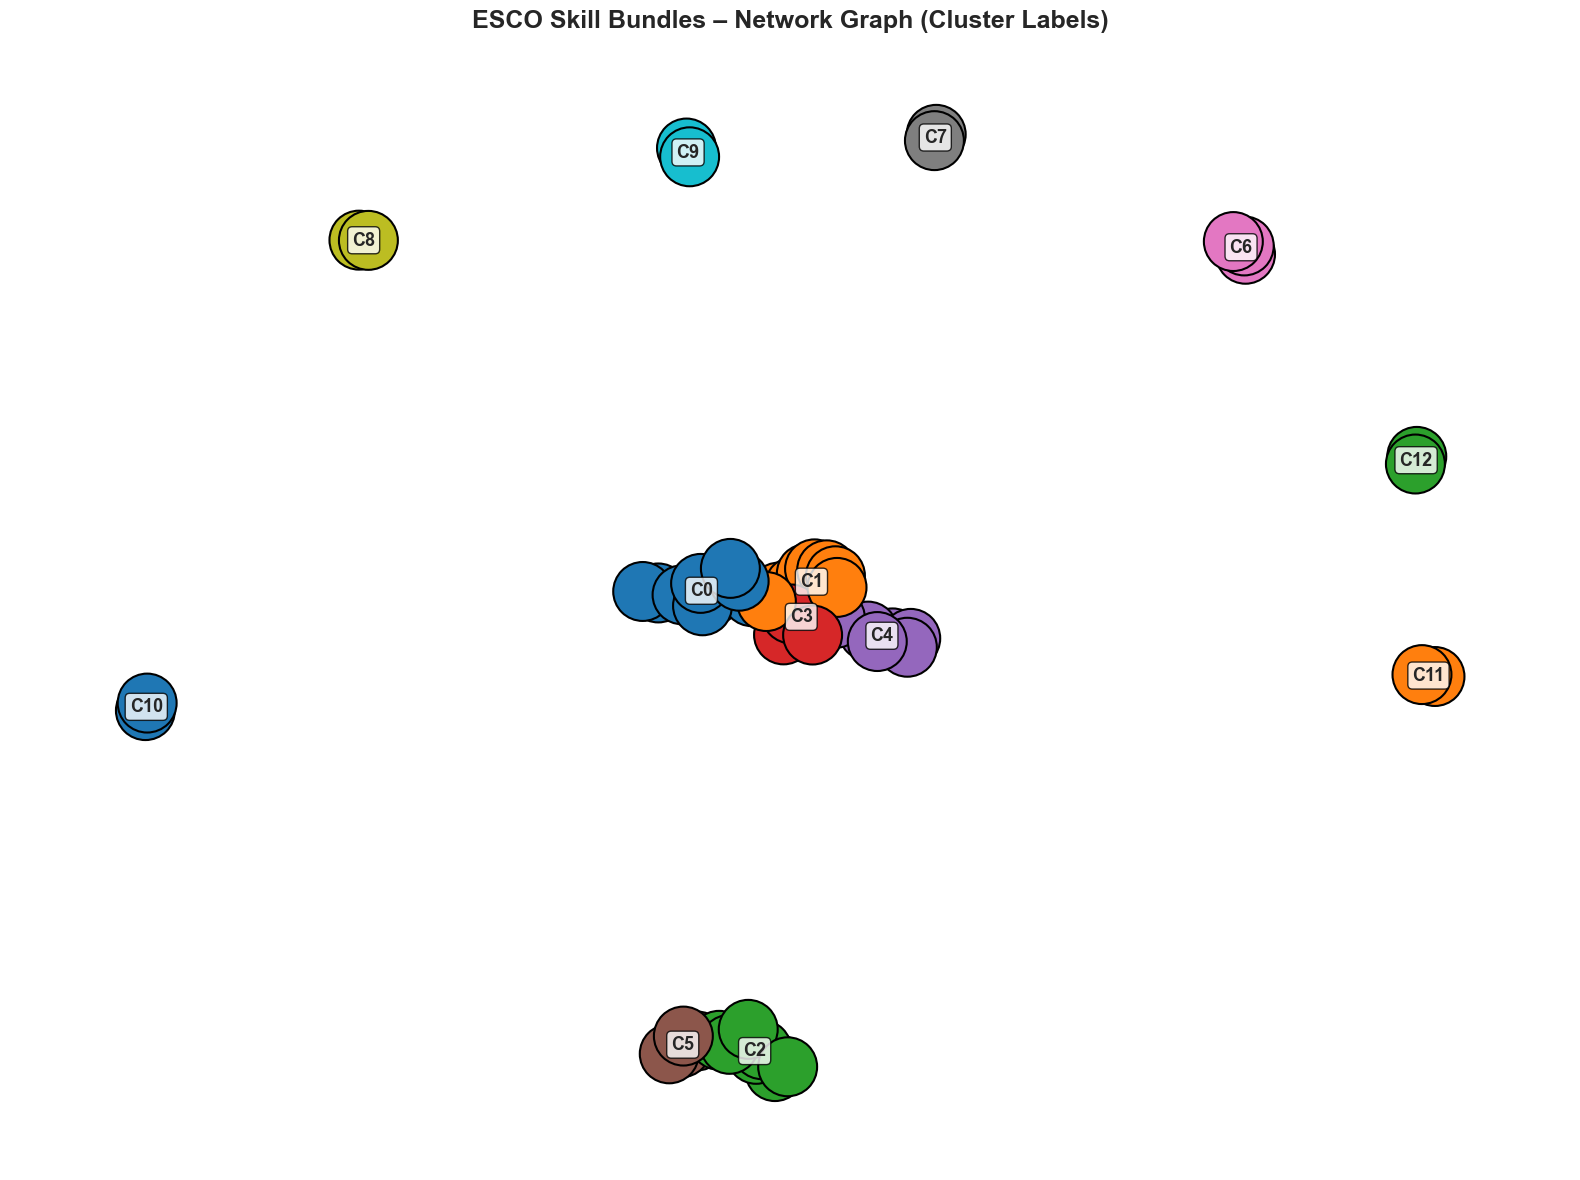

In [ ]:
node2comm = {}
for cid, comm in enumerate(communities):
    for n in comm:
        node2comm[n] = cid

cmap = plt.get_cmap("tab10")
node_colors = [cmap(node2comm[n] % 10) for n in G.nodes()]

# Layout
pos = nx.spring_layout(G, k=1.3, iterations=500, seed=42)

plt.figure(figsize=(16, 12))

# Edge weights
edges = G.edges(data=True)
weights = np.array([d["weight"] for (_, _, d) in edges])
if len(weights) > 0:
    min_w, max_w = weights.min(), weights.max()
    if max_w > min_w:
        norm_w = 1 + 4 * (weights - min_w) / (max_w - min_w)
    else:
        norm_w = np.ones_like(weights)
else:
    norm_w = []

# Vẽ edges
nx.draw_networkx_edges(G, pos, edge_color="lightgray", width=norm_w, alpha=0.7)

# Vẽ nodes (có viền)
nx.draw_networkx_nodes(
    G, pos, node_color=node_colors, node_size=1800, edgecolors="black", linewidths=1.5
)

# ======= LABEL CHO MỖI CỤM =======
# Tính tâm (mean) vị trí các node trong từng cụm

cluster_centers = {}
for cid, comm in enumerate(communities):
    xs = [pos[n][0] for n in comm]
    ys = [pos[n][1] for n in comm]
    cluster_centers[cid] = (np.mean(xs), np.mean(ys))

# Vẽ 1 label tại tâm cụm
for cid, (x, y) in cluster_centers.items():
    plt.text(
        x,
        y,
        f"C{cid}",
        fontsize=13,
        fontweight="bold",
        ha="center",
        va="center",
        bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="black", alpha=0.8),
    )

plt.title(
    "ESCO Skill Bundles – Network Graph (Cluster Labels)",
    fontsize=18,
    fontweight="bold",
)
plt.axis("off")
plt.tight_layout()
plt.show()


**Nhận xét biểu đồ ESCO Skill Bundles – Network Graph**

Biểu đồ mạng kỹ năng cho thấy các **kỹ năng ESCO không phân bố ngẫu nhiên**, mà **tự nhiên hình thành các cụm (communities)** dựa trên mức độ đồng xuất hiện trong mô tả công việc.

* **Cụm trung tâm (C0–C1–C3–C4)** có mật độ kết nối cao, đại diện cho các **kỹ năng phổ biến và liên ngành**, thường xuất hiện cùng nhau trong nhiều vị trí khác nhau. Đây là các *core skill bundles* của thị trường lao động.
* Các **cụm nằm tách biệt** (ví dụ C6, C7, C8, C9, C10, C11, C12) thường có **ít node và ít kết nối**, phản ánh các **nhóm kỹ năng chuyên biệt**, gắn với những lĩnh vực hẹp hoặc vai trò đặc thù.
* Khoảng cách không gian giữa các cụm thể hiện **mức độ khác biệt về nội dung kỹ năng**: các cụm càng xa nhau thì càng ít khi xuất hiện trong cùng một mô tả công việc.
* Việc gán nhãn cụm (C0, C1, …) giúp **tóm tắt cấu trúc kỹ năng tổng thể**, trong khi các đồ thị con (subgraph) cho từng cụm hỗ trợ phân tích chi tiết từng *skill bundle*.

**Tổng thể**, biểu đồ xác nhận rằng RQ2 đã khai phá thành công **cấu trúc kỹ năng ẩn** trong dữ liệu tuyển dụng, cho thấy thị trường lao động được tổ chức quanh một số nhóm kỹ năng cốt lõi và nhiều nhóm kỹ năng chuyên môn hóa cao.

### 4.6.2 Một số cụm kĩ năng tiêu biểu

In [ ]:
# Tạo dict: community_id -> list skill (node)
community_dict = {
    cid: sorted(list(comm))  # sắp xếp cho dễ nhìn
    for cid, comm in enumerate(communities)
}

community_dict

{0: ['adjust priorities',
  'circular economy',
  'control engineering',
  'deliver outstanding service',
  'design management',
  'drive vehicles',
  'energy storage systems',
  'lasers',
  'mobile device management',
  'supervise work',
  'wind energy'],
 1: ['biostatistics',
  'collection management',
  'counsel clients',
  'electronic communication',
  'epidemiology',
  'identify training needs',
  'immunotherapy',
  'learning management systems',
  'medical oncology',
  'political science',
  'transplantation'],
 2: ['biomarkers',
  'biometrics',
  'histology',
  'instrumentation equipment',
  'reverse engineering',
  'rheumatology',
  'scientific literature',
  'think analytically',
  'tobacco products'],
 3: ['accounting entries',
  'capacity building',
  'contact customers',
  'environmental policy',
  'policy analysis',
  'process applications',
  'quantum computing',
  'solve technical problems'],
 4: ['computer programming',
  'improve business processes',
  'iterative devel

**Nhận xét kết quả khai phá Skill Bundles**

Kết quả cho thấy các kỹ năng ESCO đã được **phân nhóm thành 13 cụm (communities)** dựa trên mức độ đồng xuất hiện trong mô tả công việc. Mỗi cụm đại diện cho một **skill bundle** – tập hợp các kỹ năng thường được yêu cầu cùng nhau trong thực tế tuyển dụng.

**1. Cấu trúc chung của các cụm**

* Các cụm có **kích thước nhỏ (2–11 kỹ năng)**, cho thấy ngưỡng lọc luật (lift & confidence) đã **loại bỏ hiệu quả nhiễu**, chỉ giữ lại các mối quan hệ kỹ năng đủ mạnh.
* Phần lớn cụm có **chủ đề tương đối rõ ràng**, phản ánh các lĩnh vực nghề nghiệp hoặc chức năng chuyên môn cụ thể.

**2. Các nhóm kỹ năng tiêu biểu**

* **Kỹ thuật – Công nghệ – Năng lượng**
  Ví dụ:

  * Cụm 0: *control engineering, wind energy, energy storage systems*
  * Cụm 4 & 6: *computer programming, iterative development, materials/packaging engineering*
    → Phản ánh các bộ kỹ năng kỹ thuật liên quan đến **engineering, sản xuất và chuyển đổi năng lượng**.

* **Y tế – Sinh học – Khoa học đời sống**
  Ví dụ:

  * Cụm 1, 2, 5, 11: *epidemiology, immunotherapy, histology, psychiatric disorders, neonatology*
    → Thể hiện rõ các **skill bundles chuyên sâu trong healthcare và biomedical**, ít trùng lặp với lĩnh vực khác.

* **Quản lý – Chính sách – Luật**
  Ví dụ:

  * Cụm 3 & 7: *policy analysis, environmental policy, corporate law, maintain privacy*
    → Phản ánh các kỹ năng mang tính **quản trị, pháp lý và hoạch định chính sách**.

* **Kỹ năng mềm & quản lý con người**
  Ví dụ:

  * Cụm 12: *coach employees, delegate responsibilities*
    → Cho thấy các kỹ năng quản lý nhân sự cũng hình thành **bundle riêng**, dù số lượng nhỏ.

**3. Các cụm nhỏ và trường hợp “lệch ngữ cảnh”**

* Một số cụm rất nhỏ (2 kỹ năng) như:

  * *boxing – prescribe medication*
  * *analytical chemistry – pesticides*
    → Đây có thể là **ngách nghề nghiệp rất hẹp**, hoặc hệ quả của **đồng xuất hiện hiếm nhưng có lift cao**. Điều này là chấp nhận được trong khai phá luật, và phản ánh tính đa dạng của dữ liệu tuyển dụng.

**4. Đánh giá tổng thể**

* Kết quả **không sao chép lại thông tin sẵn có trong title**, mà khai phá **mối liên kết ẩn giữa các kỹ năng ESCO** dựa trên dữ liệu thực tế.
* Các skill bundles thu được có thể:

  * Hỗ trợ **thiết kế chương trình đào tạo theo nhóm kỹ năng**
  * Gợi ý **lộ trình học kỹ năng** cho người lao động
  * Giúp nhà tuyển dụng hiểu rõ **các bộ kỹ năng đi kèm nhau**, thay vì nhìn từng kỹ năng đơn lẻ

**Kết luận:**
RQ2 đã khai phá thành công cấu trúc kỹ năng tiềm ẩn của thị trường lao động, cho thấy kỹ năng không tồn tại độc lập mà được tổ chức thành các *skill bundles* đặc trưng theo lĩnh vực và vai trò nghề nghiệp.

Tạo nhãn

In [ ]:
auto_cluster_names = {}

for cid, skills in community_dict.items():
    doc = " ".join(skills)
    vectorizer = TfidfVectorizer(stop_words="english")
    tfidf = vectorizer.fit_transform([doc])

    scores = tfidf.toarray()[0]
    top_ids = np.argsort(scores)[::-1][:3]  # 3 từ mạnh nhất
    keywords = [vectorizer.get_feature_names_out()[i] for i in top_ids]

    auto_cluster_names[cid] = " / ".join(keywords)

auto_cluster_names

{0: 'management / energy / vehicles',
 1: 'management / training / transplantation',
 2: 'tobacco / think / scientific',
 3: 'policy / technical / quantum',
 4: 'engineering / transportation / track',
 5: 'vocational / stem / social',
 6: 'engineering / packaging / materials',
 7: 'privacy / maintain / law',
 8: 'prescribe / medication / boxing',
 9: 'process / market / insurance',
 10: 'pesticides / chemistry / analytical',
 11: 'neonatology / loss / hearing',
 12: 'responsibilities / employees / delegate'}

In [ ]:
def plot_community(G, community, cid):
    subG = G.subgraph(list(community))

    pos = nx.spring_layout(subG, k=1.2, iterations=400, seed=42)
    plt.figure(figsize=(16, 12))

    nx.draw_networkx_nodes(
        subG, pos, node_size=2400, node_color="#4A90E2", edgecolors="black"
    )

    nx.draw_networkx_edges(subG, pos, width=2, alpha=0.7, edge_color="gray")

    nx.draw_networkx_labels(subG, pos, font_size=11, font_weight="bold")

    # plt.title(f"Skill Bundle Cluster {auto_cluster_names[cid]}", fontsize=16)
    plt.title(f"cluster {cid}: {auto_cluster_names[cid]}", fontsize=16)
    plt.axis("off")
    plt.show()


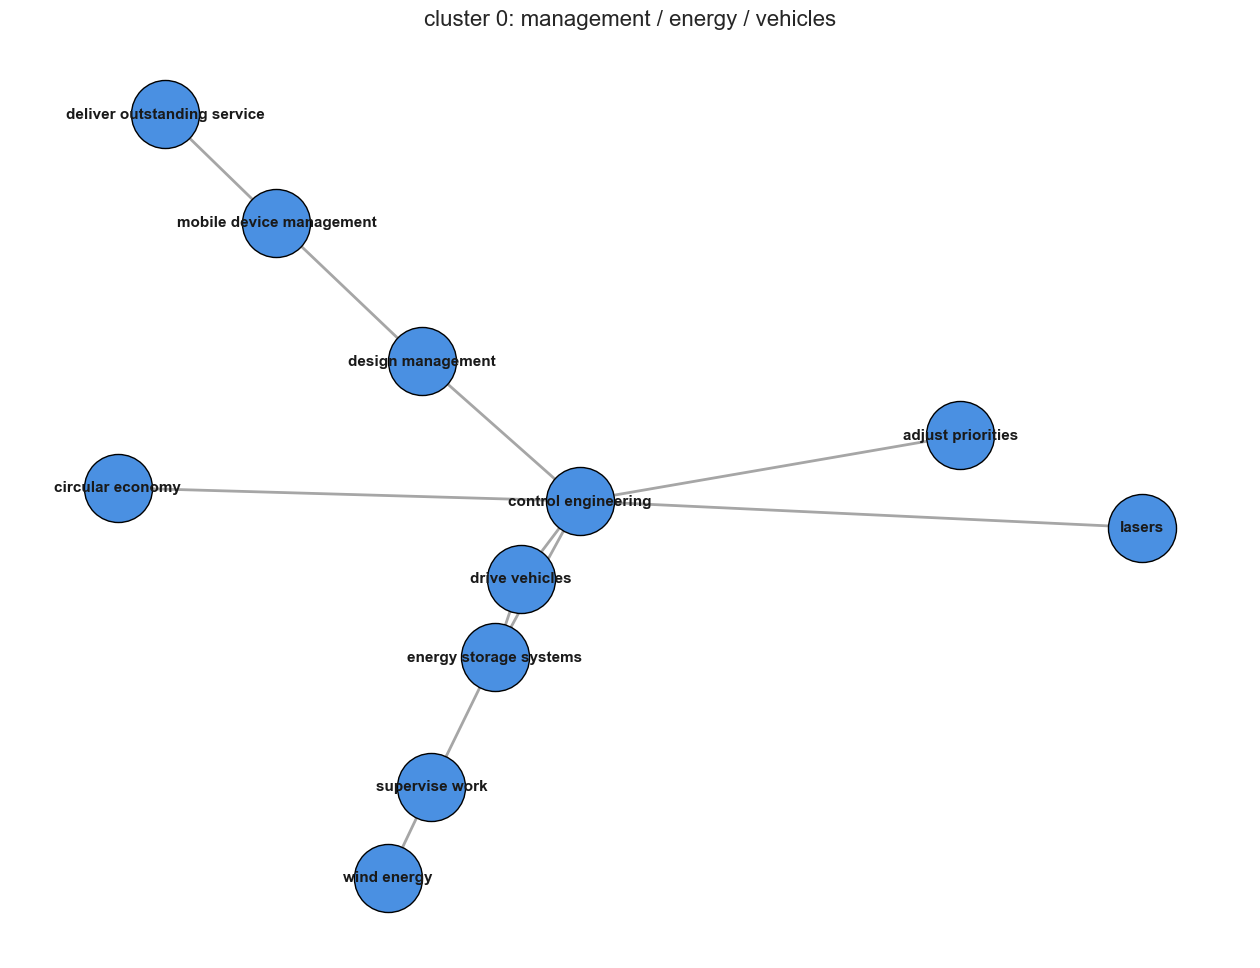

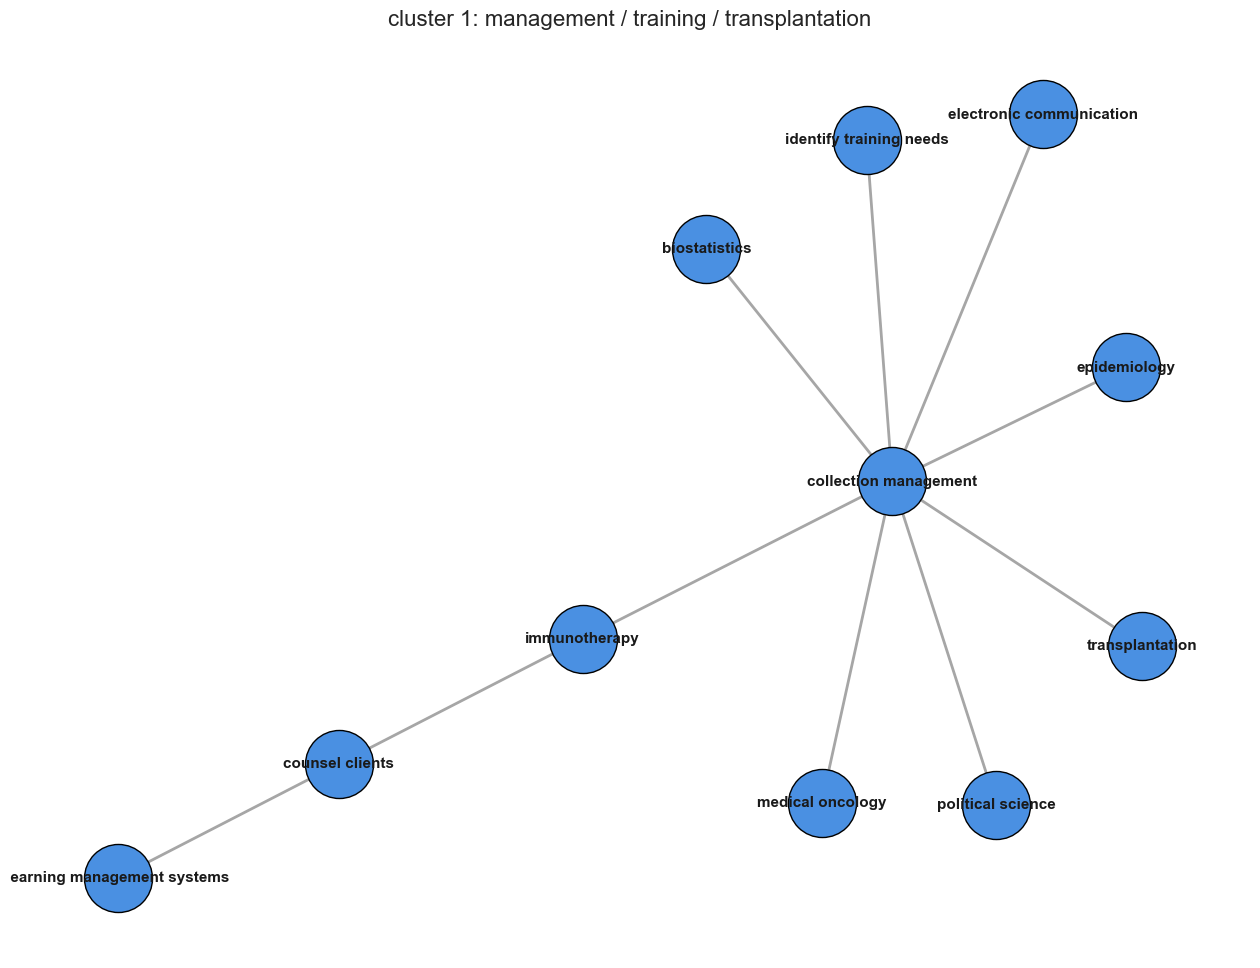

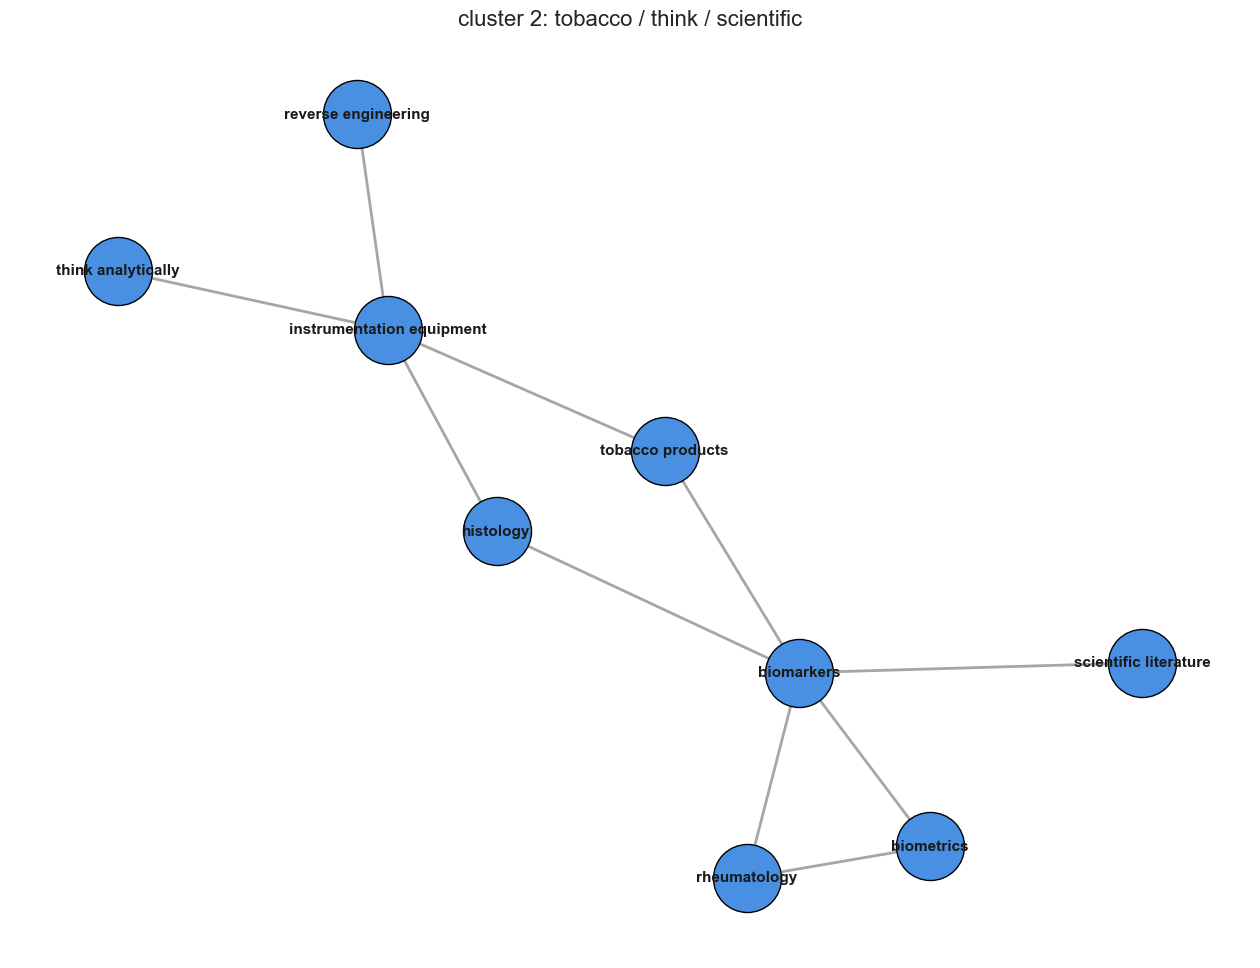

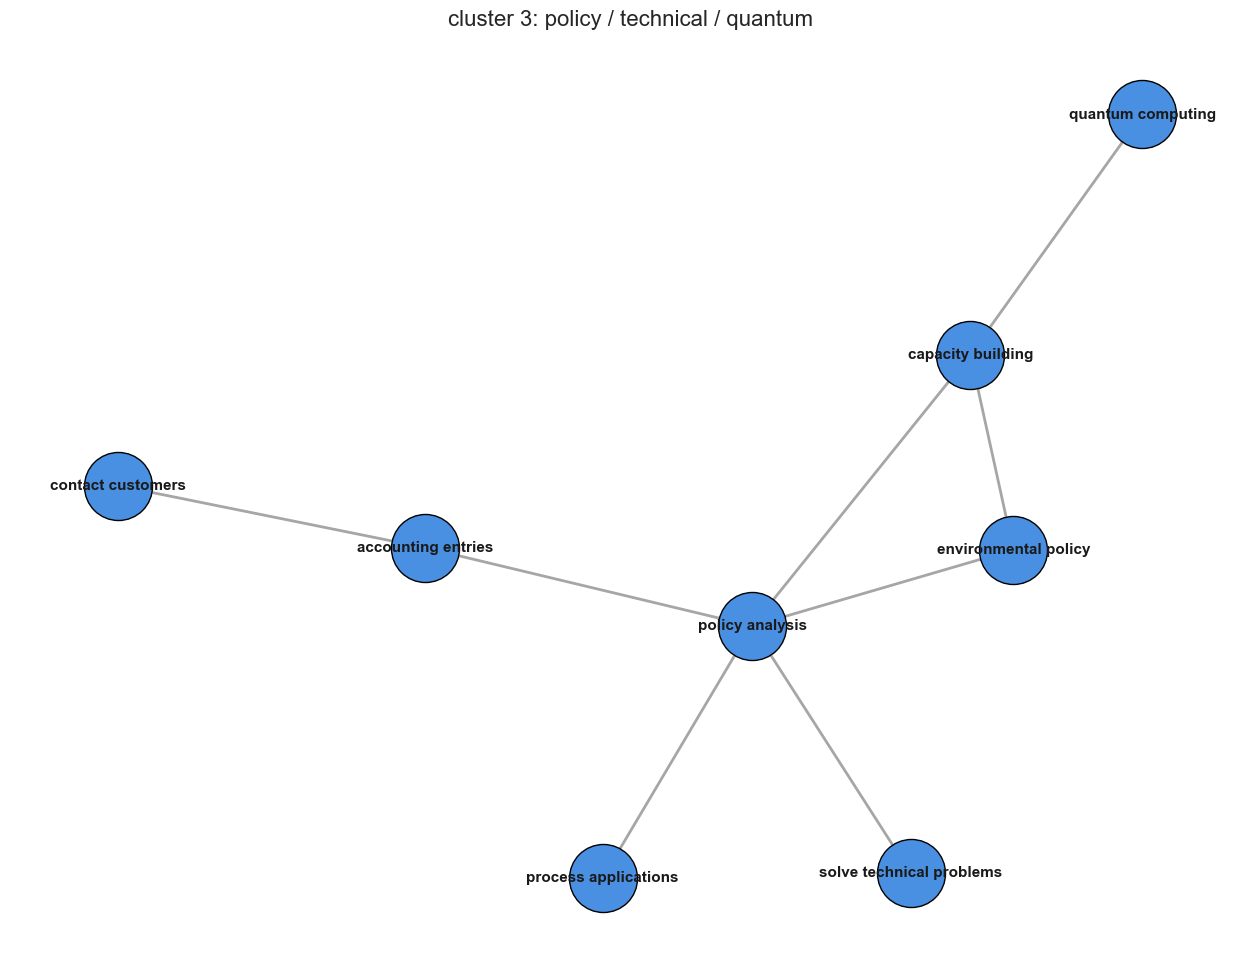

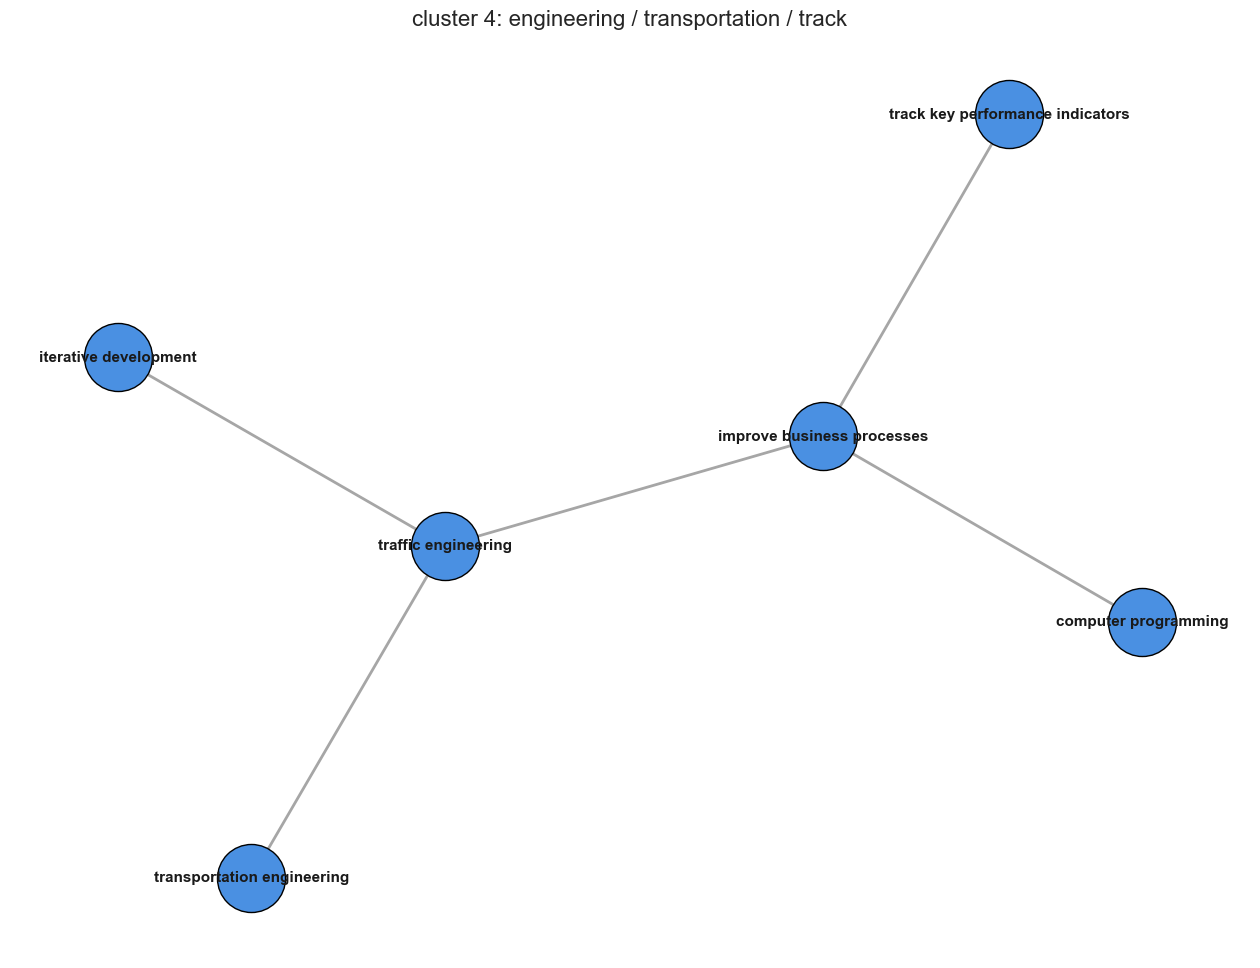

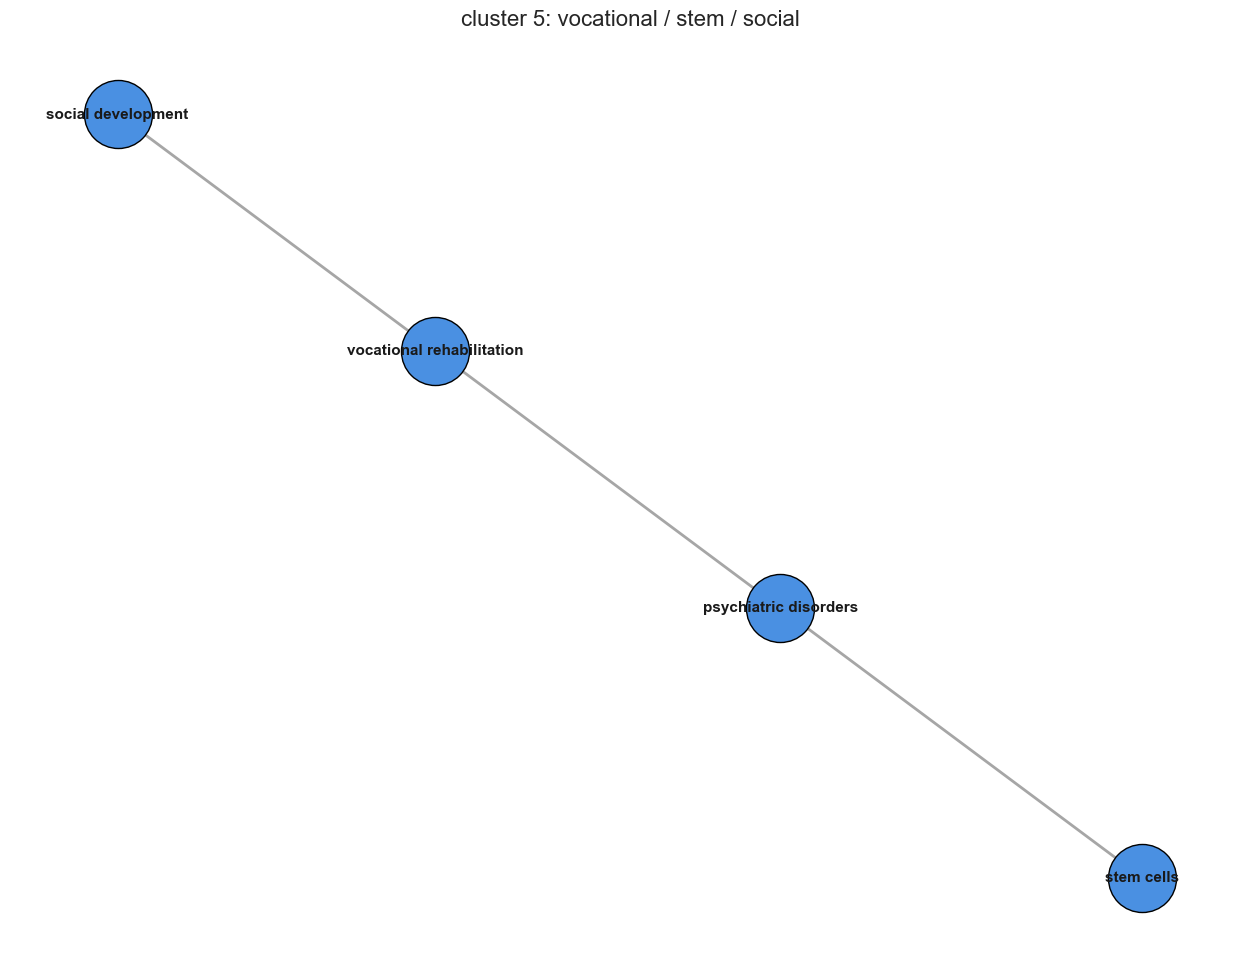

In [ ]:
for cid, comm in enumerate(communities):
    if len(comm) >= 4:
        plot_community(G, comm, cid)

## 4.7 Kết luận

Thông qua việc kết hợp **ESCO skills ontology** với phân tích đồng xuất hiện kỹ năng trong mô tả công việc, nghiên cứu đã khai phá thành công các **skill bundles** – những nhóm kỹ năng có xu hướng xuất hiện cùng nhau trong thực tế tuyển dụng. Bằng cách sử dụng các thước đo **support, confidence và lift**, các mối quan hệ kỹ năng yếu hoặc ngẫu nhiên đã được loại bỏ, giúp tập trung vào những liên kết có ý nghĩa thống kê và giá trị thực tiễn.

Kết quả cho thấy các kỹ năng không tồn tại độc lập mà được tổ chức thành các **cụm kỹ năng đặc trưng theo lĩnh vực**, bao gồm các nhóm nổi bật như kỹ thuật – công nghệ – năng lượng, y tế – khoa học đời sống, quản lý – chính sách – pháp lý, cũng như các nhóm kỹ năng quản trị và kỹ năng mềm. Các skill bundles thu được phản ánh sát nhu cầu của thị trường lao động, vì chúng được trích xuất trực tiếp từ dữ liệu tuyển dụng thực tế thay vì dựa trên phân loại lý thuyết sẵn có.

Như vậy, **RQ2 đã làm rõ cấu trúc kỹ năng ẩn của thị trường lao động**, cung cấp góc nhìn sâu hơn về cách các kỹ năng được kết hợp trong từng vai trò nghề nghiệp. Kết quả này có tiềm năng ứng dụng trong thiết kế chương trình đào tạo, tư vấn nghề nghiệp, cũng như hỗ trợ người lao động xác định các bộ kỹ năng cần phát triển để phù hợp với yêu cầu tuyển dụng hiện nay.

# 5. RQ3 – Phân tích & dự đoán lương

## 5.1 Tiền xử lí riêng cho việc chạy mô hình

In [ ]:
job_merged.columns

Index(['job_id', 'company_name', 'title', 'max_salary', 'pay_period',
       'location', 'company_id', 'views', 'med_salary', 'min_salary',
       'formatted_work_type', 'applies', 'original_listed_time',
       'remote_allowed', 'job_posting_url', 'application_url',
       'application_type', 'expiry', 'closed_time',
       'formatted_experience_level', 'skills_desc', 'listed_time',
       'posting_domain', 'sponsored', 'work_type', 'currency',
       'compensation_type', 'normalized_salary', 'zip_code_x', 'fips', 'name',
       'company_size', 'state', 'country', 'city', 'zip_code_y', 'address',
       'url', 'description', 'employee_count', 'follower_count',
       'linkedin_skills', 'desc_len', 'salary_annual', 'log_salary',
       'description_norm', 'seniority', 'skills_list'],
      dtype='object')

In [ ]:
df = job_merged.copy()


def _to_num(s):
    return pd.to_numeric(s, errors="coerce")


def list_len(x):
    return len(x) if isinstance(x, list) else 0


# period_mult = {
#     "HOUR": 2080,   # 40h/week * 52
#     "DAY": 260,     # 5d/week * 52
#     "WEEK": 52,
#     "MONTH": 12,
#     "YEAR": 1
# }

df["pay_period_std"] = df["pay_period"].astype(str).str.upper().str.strip()
# df["period_mult"] = df["pay_period_std"].map(period_mult)


df["num_skills"] = df["skills_list"].apply(list_len)
df["num_linkedin_skills"] = df["linkedin_skills"].apply(list_len)


# apply_rate
df["apply_rate"] = _to_num(df["applies"]) / (_to_num(df["views"]) + 1)

df["remote_allowed"] = _to_num(df["remote_allowed"])

df = df[df["salary_annual"].notna()].copy()
# df = df[df["salary_annual"] > 0].copy()


df["log_salary"] = np.log1p(df["salary_annual"])

## 5.2 Biểu đồ so sánh lương theo số lượng kĩ năng

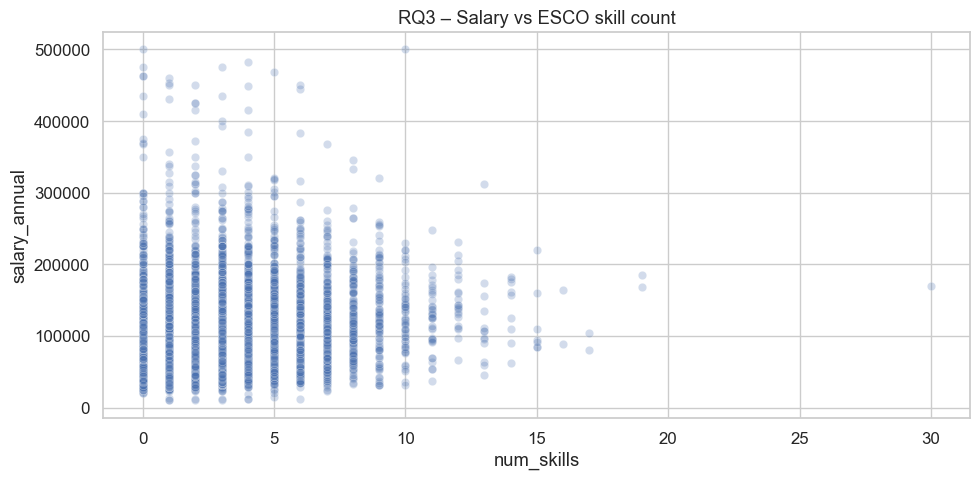

In [ ]:
sns.scatterplot(
    data=df.sample(min(len(df), 8000), random_state=42),
    x="num_skills",
    y="salary_annual",
    alpha=0.25,
)
plt.title("RQ3 – Salary vs ESCO skill count")
plt.tight_layout()
plt.show()

## 5.3 Chọn features

**Nguyên tắc chung**

* Chỉ sử dụng các thông tin **có sẵn trong tin tuyển dụng trước khi biết lương**.
* Loại bỏ các biến có nguy cơ **data leakage** (liên quan trực tiếp đến lương).
* Nhóm feature theo các **giả thuyết kinh tế – thị trường lao động**.

**Nhóm feature được sử dụng**

* **Đặc điểm công việc**: `formatted_experience_level`, `seniority` (từ title), `work_type`, `formatted_work_type`, `remote_allowed`, `desc_len`
* **Kỹ năng**: `num_skills` (ESCO), `num_linkedin_skills`
* **Quy mô doanh nghiệp**: `company_size`, `employee_count`, `follower_count`
* **Địa lý / thị trường**: `country`, `state`, `city`, `country_mean_salary` (tính trên tập train)
* **Mức độ cạnh tranh**: `views`, `applies`, `apply_rate`

**Các feature không sử dụng (tránh leakage)**

* `min_salary`, `max_salary`, `med_salary`
* `pay_period`, `currency`
* Các biến dẫn xuất trực tiếp từ lương

Cách lựa chọn này giúp mô hình tập trung vào **các yếu tố thực sự ảnh hưởng đến lương**, đồng thời đảm bảo kết quả phân tích phản ánh đúng mối quan hệ giữa thông tin tuyển dụng và mức lương được công bố.

In [ ]:
target_col = "log_salary"

# NO leakage columns:
# Do NOT include: min_salary, max_salary, med_salary, salary_raw, salary_annual, pay_period, currency
leak_cols = set(
    [
        "min_salary",
        "max_salary",
        "med_salary",
        "salary_raw",
        "salary_annual",
        "pay_period",
        "currency",
        "period_mult",
        "pay_period_std",
    ]
)

numeric_features = [
    "views",
    "applies",
    "employee_count",
    "follower_count",
    "desc_len",
    "num_skills",
    "num_linkedin_skills",
    "apply_rate",
    "remote_allowed",
    # country_mean_salary sẽ thêm sau khi tạo từ train
    "country_mean_salary",
]

categorical_features = [
    "country",
    "state",
    "city",
    "formatted_experience_level",
    "formatted_work_type",
    "work_type",
    "company_size",
    "application_type",
    "seniority",
]

# keep only existing and not leakage
numeric_features = [
    c for c in numeric_features if (c in df.columns and c not in leak_cols)
]
categorical_features = [
    c for c in categorical_features if (c in df.columns and c not in leak_cols)
]

print(f"numeric features: {numeric_features}")
print(f"categorical features: {categorical_features}")

numeric features: ['views', 'applies', 'employee_count', 'follower_count', 'desc_len', 'num_skills', 'num_linkedin_skills', 'apply_rate', 'remote_allowed']
categorical features: ['country', 'state', 'city', 'formatted_experience_level', 'formatted_work_type', 'work_type', 'company_size', 'application_type', 'seniority']


## 5.4 Chia tập train

In [ ]:
X = df[numeric_features + categorical_features].copy()
y = df[target_col].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 5.5 Fit cột country_mean_salary trên tập train

**Giải thích biến `country_mean_salary`**

Biến `country_mean_salary` được xây dựng nhằm phản ánh **mặt bằng lương trung bình theo quốc gia**, đóng vai trò như một biến ngữ cảnh (context feature) cho mô hình dự đoán lương. Biến này được tính bằng **mức lương trung bình của các job trong cùng quốc gia**, **chỉ trên tập huấn luyện**, sau đó ánh xạ sang tập kiểm tra để tránh hiện tượng *data leakage*.

Việc đưa `country_mean_salary` vào mô hình giúp tách bạch ảnh hưởng của **yếu tố địa lý** khỏi các yếu tố khác như kỹ năng, kinh nghiệm hay quy mô doanh nghiệp. Nhờ đó, mô hình có thể đánh giá rõ hơn mức độ đóng góp tương đối của từng nhóm yếu tố đối với mức lương được công bố.

In [ ]:
# Fit country_mean_salary on TRAIN only
if "country" in X_train.columns:
    train_country_mean = (
        pd.DataFrame({"country": X_train["country"], "salary": np.expm1(y_train)})
        .groupby("country")["salary"]
        .mean()
    )
    X_train["country_mean_salary"] = X_train["country"].map(train_country_mean)
    X_test["country_mean_salary"] = X_test["country"].map(train_country_mean)

# if unseen countries in test -> fill with global mean (train)
global_mean = np.expm1(y_train).mean()
if "country_mean_salary" in X_train.columns:
    X_train["country_mean_salary"] = X_train["country_mean_salary"].fillna(global_mean)
    X_test["country_mean_salary"] = X_test["country_mean_salary"].fillna(global_mean)

print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)
print("Numeric:", numeric_features)
print("Categorical:", categorical_features)


Train shape: (28448, 19) | Test shape: (7112, 19)
Numeric: ['views', 'applies', 'employee_count', 'follower_count', 'desc_len', 'num_skills', 'num_linkedin_skills', 'apply_rate', 'remote_allowed']
Categorical: ['country', 'state', 'city', 'formatted_experience_level', 'formatted_work_type', 'work_type', 'company_size', 'application_type', 'seniority']


## 5.6 Preprocess + RandomForest model 

**Pipeline tiền xử lý và mô hình dự đoán lương (RQ3)**

Pipeline được xây dựng nhằm đảm bảo **tiền xử lý dữ liệu và huấn luyện mô hình được thực hiện một cách nhất quán**.

* **Numeric features** được xử lý bằng cách:

  * Điền giá trị thiếu bằng **median** (giảm ảnh hưởng của outlier).
  * Chuẩn hóa bằng **StandardScaler** để đưa các biến về cùng thang đo.

* **Categorical features** được xử lý bằng cách:

  * Điền giá trị thiếu bằng **giá trị xuất hiện nhiều nhất**.
  * Mã hóa **One-Hot Encoding**, với `handle_unknown="ignore"` để đảm bảo mô hình hoạt động ổn định khi gặp giá trị mới ở tập kiểm tra.

* **ColumnTransformer** kết hợp hai nhánh tiền xử lý trên và loại bỏ các cột không sử dụng, giúp dữ liệu đầu vào phù hợp cho mô hình học máy.

**Lý do lựa chọn Random Forest cho RQ3**

Random Forest được lựa chọn làm mô hình chính trong RQ3 vì phù hợp với mục tiêu **phân tích yếu tố ảnh hưởng đến lương** hơn là tối ưu hóa độ chính xác dự đoán thuần túy.

* **Không giả định quan hệ tuyến tính**: Mức lương chịu tác động phức tạp từ nhiều yếu tố như kinh nghiệm, kỹ năng, địa lý và quy mô doanh nghiệp. Random Forest có khả năng học các quan hệ **phi tuyến và tương tác giữa các biến** mà không cần giả định trước dạng hàm.

* **Hoạt động tốt với dữ liệu hỗn hợp**: Dataset tuyển dụng gồm cả biến số (views, employee_count, số kỹ năng) và biến phân loại (quốc gia, cấp độ kinh nghiệm, loại hình công việc). Random Forest xử lý hiệu quả kiểu dữ liệu này sau bước mã hóa.

* **Ít nhạy cảm với nhiễu và outlier**: So với các mô hình tuyến tính, Random Forest ổn định hơn khi dữ liệu có phân phối lệch và nhiều giá trị ngoại lai – đặc điểm phổ biến của dữ liệu lương.

* **Khả năng diễn giải**: Thông qua các kỹ thuật như *permutation feature importance*, Random Forest cho phép xác định **những yếu tố nào ảnh hưởng mạnh nhất đến mức lương**, trực tiếp trả lời câu hỏi nghiên cứu RQ3.

* **Cân bằng giữa hiệu quả và độ phức tạp**: Random Forest cho kết quả tốt mà không đòi hỏi tinh chỉnh tham số quá phức tạp, phù hợp với phạm vi của một bài toán **khai phá dữ liệu**.

Do đó, Random Forest không chỉ là một mô hình dự đoán, mà còn là **công cụ phân tích** giúp làm rõ vai trò của từng nhóm thông tin tuyển dụng đối với mức lương được công bố.

In [ ]:
numeric_transformer = Pipeline(
    steps=[("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop",
)

rf = RandomForestRegressor(
    n_estimators=300, max_depth=24, min_samples_leaf=5, n_jobs=-1, random_state=42
)

model = Pipeline(steps=[("preprocess", preprocess), ("model", rf)])

model.fit(X_train, y_train)


,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## 5.7 Evaluation 

In [ ]:
y_pred_log = model.predict(X_test)
y_true = np.expm1(y_test)
y_pred = np.expm1(y_pred_log)

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print(f"RandomForest -> RMSE={rmse:,.0f} | MAE={mae:,.0f} | R²={r2:.3f}")

RandomForest -> RMSE=42,564 | MAE=27,068 | R²=0.445


**Đánh giá kết quả mô hình Random Forest (RQ3)**

Mô hình Random Forest đạt **RMSE = 42,564**, **MAE = 27,068** và **R² = 0.445** trên tập kiểm tra. Kết quả này cho thấy mô hình có khả năng **giải thích khoảng 44.5% độ biến thiên của mức lương**, dựa trên các thông tin có sẵn trong tin tuyển dụng.

Giá trị **R² ở mức trung bình** phản ánh rằng các yếu tố như kinh nghiệm, kỹ năng, quy mô doanh nghiệp và bối cảnh địa lý **đóng vai trò quan trọng trong việc hình thành mức lương**, nhưng chưa thể giải thích toàn bộ sự khác biệt về lương. Điều này là hợp lý trong bối cảnh dữ liệu tuyển dụng, nơi mức lương còn chịu ảnh hưởng bởi nhiều yếu tố không quan sát được như đàm phán cá nhân, chính sách nội bộ của doanh nghiệp hoặc điều kiện thị trường tại thời điểm đăng tuyển.

Sai số **MAE ≈ 27 nghìn** cho thấy mức chênh lệch trung bình giữa lương dự đoán và lương thực tế ở mức chấp nhận được đối với dữ liệu lương có độ phân tán cao. Trong khi đó, **RMSE cao hơn MAE** phản ánh sự tồn tại của một số trường hợp lương rất cao hoặc rất thấp, làm tăng sai số bình phương.

Tổng thể, kết quả cho thấy mô hình **không nhằm dự đoán chính xác tuyệt đối mức lương**, mà đóng vai trò như một công cụ khai phá giúp **định lượng mức độ ảnh hưởng của các yếu tố trong tin tuyển dụng đến lương**, qua đó trả lời hiệu quả câu hỏi nghiên cứu RQ3.

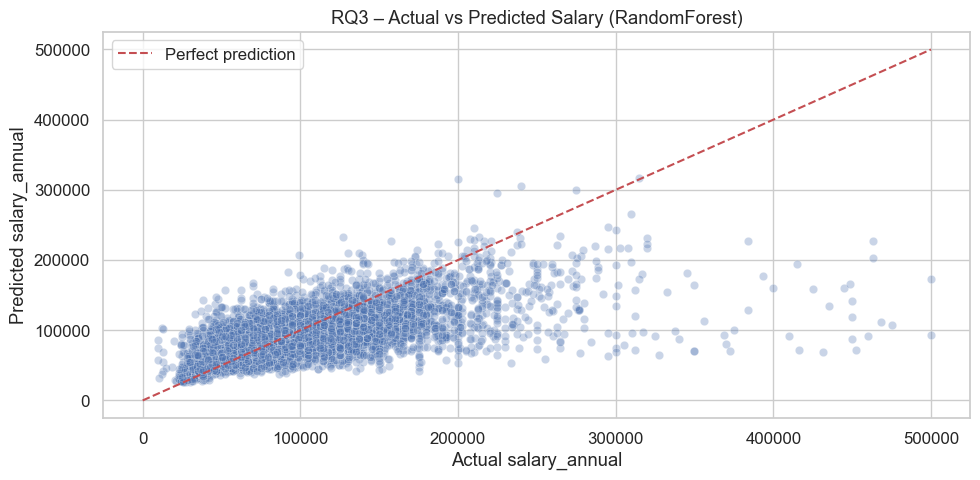

In [ ]:
sns.scatterplot(x=y_true, y=y_pred, alpha=0.30)
max_val = float(max(y_true.max(), y_pred.max()))
plt.plot([0, max_val], [0, max_val], "r--", linewidth=1.5, label="Perfect prediction")
plt.xlabel("Actual salary_annual")
plt.ylabel("Predicted salary_annual")
plt.title("RQ3 – Actual vs Predicted Salary (RandomForest)")
plt.legend()
plt.tight_layout()
plt.show()

**Nhận xét biểu đồ *Actual vs Predicted Salary* (RQ3 – Random Forest)**

Biểu đồ cho thấy **mối quan hệ dương rõ ràng** giữa lương thực tế và lương dự đoán: khi lương thực tế tăng, lương dự đoán cũng có xu hướng tăng theo. Phần lớn các điểm dữ liệu tập trung quanh đường chéo (*perfect prediction*), cho thấy mô hình đã **nắm bắt được xu hướng tổng quát của mức lương**.

Tuy nhiên, có thể quan sát thấy một số đặc điểm đáng chú ý:

* Ở **vùng lương thấp đến trung bình**, các điểm phân bố khá sát đường chéo, cho thấy mô hình dự đoán tương đối tốt trong khoảng lương phổ biến nhất của thị trường.
* Ở **mức lương cao**, các điểm có xu hướng **nằm dưới đường chéo**, phản ánh hiện tượng mô hình **đánh giá thấp (underestimate)** các vị trí lương rất cao. Đây là hiện tượng thường gặp do số lượng mẫu lương cao ít và độ biến thiên lớn.
* Độ phân tán của = lớn dần khi lương tăng, cho thấy **độ không chắc chắn trong dự đoán tăng theo mức lương**, phù hợp với thực tế thị trường lao động (lương cao chịu ảnh hưởng mạnh từ yếu tố cá nhân và doanh nghiệp).

Nhìn chung, biểu đồ xác nhận rằng mô hình Random Forest **phù hợp để phân tích xu hướng và các yếu tố ảnh hưởng đến lương**, nhưng **không nhằm mục tiêu dự đoán chính xác tuyệt đối cho từng cá nhân**, đặc biệt ở phân khúc lương rất cao.


## 5.8 Permutation Feature Importance

,feature,importance
12,formatted_experience_level,2.155542e-01
17,seniority,2.141076e-01
3,follower_count,2.020390e-01
2,employee_count,9.926180e-02
5,num_skills,7.365017e-02
4,desc_len,6.373719e-02
16,application_type,3.953535e-02
10,state,3.857401e-02
6,num_linkedin_skills,3.657205e-02
11,city,2.604502e-02


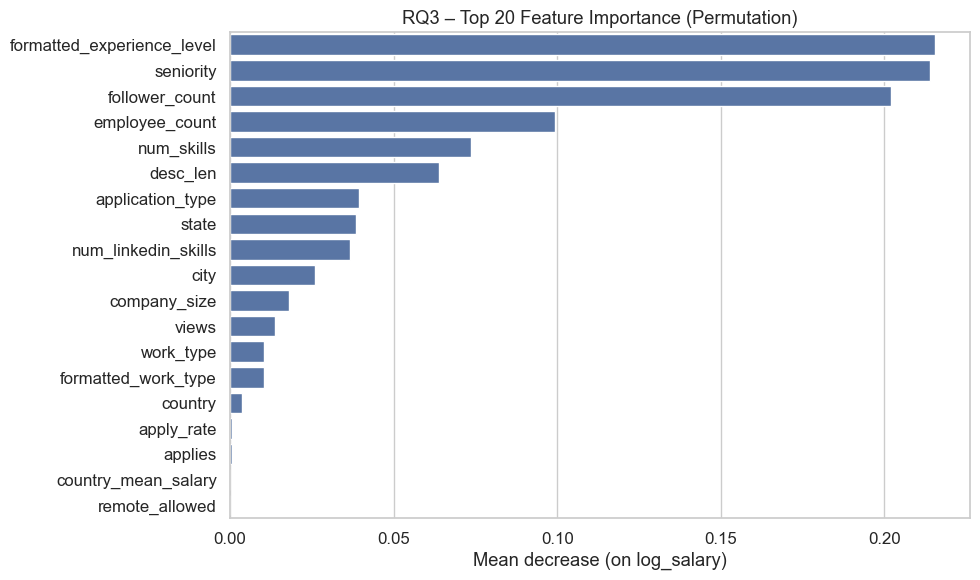

In [ ]:
# Lưu ý: permutation_importance chạy trên X_test (raw), pipeline sẽ preprocess bên trong
perm = permutation_importance(
    model, X_test, y_test, n_repeats=8, random_state=42, n_jobs=-1
)

# Feature names (raw columns) – đủ để giải thích theo nhóm yếu tố
feat_names = np.array(X_test.columns)
imp = perm.importances_mean
imp_df = pd.DataFrame({"feature": feat_names, "importance": imp}).sort_values(
    "importance", ascending=False
)

display(imp_df.head(20))

topn = 20
plt.figure(figsize=(10, 6))
sns.barplot(data=imp_df.head(topn), y="feature", x="importance")
plt.title(f"RQ3 – Top {topn} Feature Importance (Permutation)")
plt.xlabel("Mean decrease (on log_salary)")
plt.ylabel("")
plt.tight_layout()
plt.show()

**Nhận xét biểu đồ Top 20 Feature Importance (Permutation) – RQ3**

Biểu đồ thể hiện mức độ ảnh hưởng của từng đặc trưng đến khả năng dự đoán **log_salary** của mô hình Random Forest, đo bằng *permutation importance* (mức suy giảm hiệu năng khi hoán vị giá trị của biến).

**Nhận xét chính:**

* **Cấp độ kinh nghiệm (`formatted_experience_level`) và thâm niên (`seniority`)** là hai yếu tố quan trọng nhất. Điều này hoàn toàn phù hợp với thực tế thị trường lao động: mức lương tăng mạnh theo kinh nghiệm và vị trí trong tổ chức.
* **Quy mô và độ “uy tín” của công ty** (đại diện bởi `follower_count` và `employee_count`) có ảnh hưởng đáng kể, cho thấy các công ty lớn hoặc được quan tâm nhiều thường trả lương cao hơn.
* **Mức độ yêu cầu kỹ năng** (`num_skills`, `num_linkedin_skills`) và **độ dài mô tả công việc (`desc_len`)** cũng đóng vai trò quan trọng, phản ánh rằng các vị trí phức tạp, yêu cầu nhiều kỹ năng thường đi kèm mức lương cao hơn.
* Các yếu tố **hình thức tuyển dụng và bối cảnh địa lý** (`application_type`, `state`, `city`, `company_size`) có tác động trung bình, góp phần điều chỉnh mức lương nhưng không mang tính quyết định.
* Những biến như **lượt xem, lượt ứng tuyển, remote_allowed, apply_rate** và đặc biệt là **`country_mean_salary`** có mức ảnh hưởng rất thấp, cho thấy chúng không cung cấp thêm nhiều thông tin mới sau khi đã xét đến kinh nghiệm, thâm niên và đặc điểm công ty.

**Kết luận:**
Kết quả feature importance cho thấy mức lương trong dữ liệu LinkedIn **chủ yếu được quyết định bởi yếu tố con người (kinh nghiệm, thâm niên) và bối cảnh tổ chức (quy mô, độ phổ biến của công ty)**, trong khi các tín hiệu tương tác (views, applies) hoặc biến tổng hợp theo quốc gia đóng vai trò thứ yếu. Điều này giúp trả lời rõ ràng RQ3 về *những yếu tố nào ảnh hưởng đáng kể đến mức lương được công bố*.


## 5.9 Kết luận

RQ3 nhằm trả lời câu hỏi **“Những yếu tố nào trong thông tin tuyển dụng ảnh hưởng đáng kể đến mức lương được công bố, và mức độ dự đoán lương từ các yếu tố này đến đâu?”**.
Thông qua mô hình Random Forest kết hợp pipeline tiền xử lý dữ liệu, nghiên cứu đã cho thấy rằng mức lương công bố trong các bài tuyển dụng LinkedIn **không phải là ngẫu nhiên**, mà chịu ảnh hưởng rõ rệt bởi một số nhóm yếu tố chính.

Kết quả thực nghiệm cho thấy **yếu tố quan trọng nhất ảnh hưởng đến mức lương là cấp độ kinh nghiệm và thâm niên** (experience level, seniority). Điều này phản ánh đúng logic của thị trường lao động: các vị trí cấp cao hoặc yêu cầu nhiều năm kinh nghiệm thường đi kèm mức lương cao hơn. Bên cạnh đó, **đặc điểm của doanh nghiệp** như quy mô công ty và mức độ phổ biến (employee_count, follower_count) cũng có tác động đáng kể, cho thấy các công ty lớn hoặc có thương hiệu mạnh thường sẵn sàng chi trả mức lương cao hơn.

Ngoài ra, **mức độ phức tạp của công việc** – thể hiện qua số lượng kỹ năng yêu cầu và độ dài mô tả công việc – cũng góp phần giải thích sự khác biệt về lương. Ngược lại, các yếu tố mang tính tương tác như số lượt xem, số lượt ứng tuyển, hay khả năng làm việc từ xa chỉ có ảnh hưởng nhỏ, trong khi các biến tổng hợp như country_mean_salary hầu như không đóng vai trò quyết định sau khi đã xét đến các đặc trưng khác.

Về khả năng dự đoán, mô hình Random Forest đạt **R² ≈ 0.45**, cho thấy mô hình có thể giải thích được một phần đáng kể biến thiên của mức lương, dù vẫn còn sai số do các yếu tố không quan sát được (đàm phán cá nhân, phúc lợi, thưởng, hoặc thông tin nội bộ).

**Tóm lại**, RQ3 cho thấy mức lương trong dữ liệu tuyển dụng LinkedIn chịu ảnh hưởng chủ yếu bởi **kinh nghiệm, thâm niên và đặc điểm công ty**, đồng thời việc dự đoán lương từ thông tin tuyển dụng là **khả thi ở mức trung bình–khá**, đủ để rút ra các insight có ý nghĩa thực tiễn cho người tìm việc, doanh nghiệp và các nhà hoạch định chính sách lao động.


# Kết thúc